final code for training capped at 300 dishes 

In [1]:
!pip install timm==0.9.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: timm
    Found existing installation: timm 1.0.25
    Uninstalling timm-1.0.25:
      Successfully uninstalled timm-1.0.25


In [2]:
pip install timm --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: timm
    Found existing installation: timm 0.9.8
    Uninstalling timm-0.9.8:
      Successfully uninstalled timm-0.9.8
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ==================================================================================
# SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION
# Stage 1: Food-101 pretraining
# Stage 2: SehatGuru 50-class fine-tuning with max 400 training images per class
#
# Important change:
# - Dataset is split first into train/val/test.
# - Only the TRAIN split is capped to max 400 images per class.
# - Validation and test remain unchanged.
#
# Dataset replacement update:
# - Removes: Charga, Palak Paneer, Sheer khurma
# - Adds Food-101: Donut, Dumpling, French Toast
# - Each added class capped at 300 images
#
# Saves:
# - Food-101 checkpoint
# - best capped SehatGuru model checkpoint
# - last capped SehatGuru checkpoint
# - classification report
# - confidence report
# - confusion matrix
# - hard examples CSV
# - confusion-pair CSV
# - split indices JSON
# - training history CSV
# - final downloadable ZIP
# ==================================================================================


# ==================================================================================
# 0. IMPORTS / INSTALLS
# ==================================================================================

import os
import json
import time
import copy
import random
import shutil
from pathlib import Path

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


# ==================================================================================
# 1. CONFIG
# ==================================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_ENABLED = DEVICE == "cuda"

SEED = 42

IMG_SIZE = 260

# Keep 16 for safer overnight run.
# You can use 32 later if GPU memory is fine.
BATCH_SIZE = 16

NUM_WORKERS = 2

EXPECTED_CLASSES = 50

# New cap setting:
# Only training data is capped.
TRAIN_CAP_PER_CLASS = 300

# Food-101 pretraining
USE_FOOD101_PRETRAINING = True
REUSE_FOOD101_CKPT_IF_EXISTS = True
FOOD101_EPOCHS = 3
FOOD101_ROOT = "/kaggle/working/torchvision_food101"

# SehatGuru fine-tuning
# Total epochs = 3 + 8 + 18 = 29
PHASES = [
    {
        "name": "head_only",
        "epochs": 3,
        "mode": "head_only",
        "backbone_lr": 0.0,
        "head_lr": 3e-4,
    },
    {
        "name": "last_stage",
        "epochs": 8,
        "mode": "last_stage",
        "backbone_lr": 1e-5,
        "head_lr": 1e-4,
    },
    {
        "name": "full_finetune",
        "epochs": 18,
        "mode": "all",
        "backbone_lr": 5e-6,
        "head_lr": 5e-5,
    },
]

USE_FOCAL_LOSS = True
USE_WEIGHTED_SAMPLER = False

# Mixup kept; CutMix removed.
USE_MIXUP_CUTMIX = True
USE_EMA = True
USE_TRIVIAL_AUGMENT = True

MIXUP_ALPHA = 0.2
EMA_DECAY = 0.999

WEIGHT_DECAY = 1e-2
GRAD_CLIP = 1.0

# Confirmed SehatGuru 50-class dataset path
DATASET_DIR = "/kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset"

# Remove these from the main dataset
REMOVE_MAIN_CLASSES = {"Charga", "Palak Paneer", "Sheer Khurma"}


# Add these Food-101 classes, capped at 300 each
EXTRA_FOOD101_CLASS_SPECS = [
    {
        "display_name": "Donut",
        "keywords": ["donuts", "donut", "doughnuts", "doughnut"],
    },
    {
        "display_name": "Dumpling",
        "keywords": ["dumplings", "dumpling"],
    },
    {
        "display_name": "French Toast",
        "keywords": ["french toast", "french_toast"],
    },
]

EXTRA_CLASS_MAX = 300

# Output files — capped version names so old model is not overwritten
FOOD101_CKPT = "/kaggle/working/stage1_food101_convnext_tiny.pth"

FINAL_CKPT = "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"
LAST_CKPT = "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_last.pth"

CONFUSION_PNG = "/kaggle/working/confusion_matrix_50_classes_capped300.png"
CONFIDENCE_CSV = "/kaggle/working/confidence_report_50_classes_capped300.csv"
REPORT_CSV = "/kaggle/working/classification_report_50_classes_capped300.csv"
HARD_EXAMPLES_CSV = "/kaggle/working/hard_examples_50_classes_capped300.csv"
CONFUSION_PAIRS_CSV = "/kaggle/working/top_confusion_pairs_50_classes_capped300.csv"
SPLIT_JSON = "/kaggle/working/sehatguru_50_split_indices_capped300.json"
TRAINING_HISTORY_CSV = "/kaggle/working/training_history_50_classes_capped300.csv"
OUTPUT_ZIP = "/kaggle/working/sehatguru_50_capped300_training_outputs.zip"


# ==================================================================================
# 2. AMP HELPERS
# ==================================================================================

try:
    from torch.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler("cuda", enabled=AMP_ENABLED)

    def amp_context():
        return autocast("cuda", enabled=AMP_ENABLED)

except Exception:
    from torch.cuda.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler(enabled=AMP_ENABLED)

    def amp_context():
        return autocast(enabled=AMP_ENABLED)


# ==================================================================================
# 3. REPRODUCIBILITY
# ==================================================================================

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


seed_everything(SEED)

print("=" * 90)
print("SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION")
print("=" * 90)
print("Device:", DEVICE)
print("AMP enabled:", AMP_ENABLED)
print("Food-101 pretraining:", USE_FOOD101_PRETRAINING)
print("Reuse Food-101 checkpoint if exists:", REUSE_FOOD101_CKPT_IF_EXISTS)
print("Food-101 root:", FOOD101_ROOT)
print("SehatGuru dataset:", DATASET_DIR)
print("Batch size:", BATCH_SIZE)
print("Training cap per class:", TRAIN_CAP_PER_CLASS)
print("Remove main classes:", REMOVE_MAIN_CLASSES)
print("Add Food-101 classes:", [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS])


# ==================================================================================
# 4. TRANSFORMS
# ==================================================================================

def build_train_transform():
    aug_list = [
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.45, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(12),
    ]

    if USE_TRIVIAL_AUGMENT:
        try:
            aug_list.append(transforms.TrivialAugmentWide())
            print("\nUsing TrivialAugmentWide.")
        except AttributeError:
            print("\nTrivialAugmentWide not available. Skipping it.")

    aug_list.extend([
        transforms.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.20,
            hue=0.01,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])

    return transforms.Compose(aug_list)


train_transform = build_train_transform()

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])


# ==================================================================================
# 5. SAFE IMAGEFOLDER + SUBSET WRAPPER
# ==================================================================================

class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, *args, max_retries=10, **kwargs):
        super().__init__(*args, **kwargs)
        self.max_retries = max_retries
        self.bad_images_seen = 0

    def __getitem__(self, index):
        for offset in range(self.max_retries):
            safe_index = (index + offset) % len(self.samples)
            path, target = self.samples[safe_index]

            try:
                sample = self.loader(path)

                if self.transform is not None:
                    sample = self.transform(sample)

                if self.target_transform is not None:
                    target = self.target_transform(target)

                return sample, target

            except Exception as e:
                self.bad_images_seen += 1

                if self.bad_images_seen <= 20:
                    print(f"Skipping unreadable image: {path} | {type(e).__name__}")

                continue

        raise RuntimeError(f"Could not load a valid image near index {index}")


class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, label = self.base_dataset[real_idx]

        if self.transform:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.indices)


# ==================================================================================
# 6. DATASET HELPERS
# ==================================================================================

def get_targets_from_dataset(dataset):
    if hasattr(dataset, "targets"):
        return list(dataset.targets)

    targets = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        targets.append(label)

    return targets


def stratified_split_indices(labels, train_ratio=0.80, val_ratio=0.10, test_ratio=0.10, seed=42):
    labels = np.array(labels)
    all_indices = np.arange(len(labels))

    ratio_sum = train_ratio + val_ratio + test_ratio

    if abs(ratio_sum - 1.0) > 1e-6:
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")

    counts = np.bincount(labels)

    if counts.min() < 3:
        print("\nWarning: Some classes have fewer than 3 samples. Falling back to random split.")

        rng = np.random.default_rng(seed)
        rng.shuffle(all_indices)

        train_end = int(train_ratio * len(all_indices))
        val_end = train_end + int(val_ratio * len(all_indices))

        return (
            all_indices[:train_end].tolist(),
            all_indices[train_end:val_end].tolist(),
            all_indices[val_end:].tolist(),
        )

    if test_ratio == 0:
        train_idx, val_idx = train_test_split(
            all_indices,
            test_size=val_ratio,
            random_state=seed,
            stratify=labels,
        )

        return train_idx.tolist(), val_idx.tolist(), []

    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=(1 - train_ratio),
        random_state=seed,
        stratify=labels,
    )

    temp_labels = labels[temp_idx]
    val_fraction_of_temp = val_ratio / (val_ratio + test_ratio)

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1 - val_fraction_of_temp),
        random_state=seed,
        stratify=temp_labels,
    )

    return train_idx.tolist(), val_idx.tolist(), test_idx.tolist()


def cap_train_indices_per_class(train_indices, labels, max_per_class=400, seed=42):
    """
    Caps only the training set.
    Validation and test are left untouched.
    """

    rng = np.random.default_rng(seed)
    labels = np.array(labels)

    class_to_indices = {}

    for idx in train_indices:
        label = int(labels[idx])
        class_to_indices.setdefault(label, []).append(idx)

    capped_indices = []
    cap_report = []

    for label in sorted(class_to_indices.keys()):
        indices = class_to_indices[label]
        before_count = len(indices)

        if before_count > max_per_class:
            selected = rng.choice(indices, size=max_per_class, replace=False).tolist()
        else:
            selected = indices

        after_count = len(selected)
        capped_indices.extend(selected)

        cap_report.append({
            "class_id": label,
            "before_cap": before_count,
            "after_cap": after_count,
            "removed": before_count - after_count,
        })

    rng.shuffle(capped_indices)

    return capped_indices, pd.DataFrame(cap_report)


def make_class_weights_from_labels(labels, indices, n_classes):
    targets = [labels[i] for i in indices]
    counts = np.bincount(targets, minlength=n_classes)

    weights = 1.0 / np.maximum(counts, 1)
    weights = weights / weights.mean()

    return torch.tensor(weights, dtype=torch.float32), counts


def make_weighted_sampler_from_labels(labels, indices, n_classes):
    class_weights, counts = make_class_weights_from_labels(labels, indices, n_classes)

    targets = [labels[i] for i in indices]
    sample_weights = [class_weights[t].item() for t in targets]

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

    return sampler, counts


def normalize_name(name):
    return str(name).lower().replace("_", " ").replace("-", " ").strip()


def exact_class_lookup(class_names, keyword_options):
    normalized = {normalize_name(name): name for name in class_names}

    for keywords in keyword_options:
        if isinstance(keywords, str):
            keywords = [keywords]

        for keyword in keywords:
            key = normalize_name(keyword)
            if key in normalized:
                return normalized[key]

    raise ValueError(f"Could not find a matching class for keywords: {keyword_options}")


def resolve_dataset_item_path(dataset, index, fallback_prefix="dataset"):
    for attr in ("samples", "imgs"):
        if hasattr(dataset, attr):
            items = getattr(dataset, attr)
            if 0 <= index < len(items):
                return items[index][0]

    for attr in ("images", "_images"):
        if hasattr(dataset, attr):
            items = getattr(dataset, attr)
            if 0 <= index < len(items):
                item = items[index]
                if isinstance(item, (tuple, list)):
                    return item[0]
                return item

    return f"{fallback_prefix}:{index}"


class MultiSourceRemappedDataset(torch.utils.data.Dataset):
    def __init__(self, sources, entries, class_names, transform=None):
        self.sources = sources
        self.entries = list(entries)
        self.classes = list(class_names)
        self.transform = transform
        self.targets = [label for _, _, label in self.entries]
        self.sample_paths = [
            resolve_dataset_item_path(self.sources[source_name], source_idx, source_name)
            for source_name, source_idx, _ in self.entries
        ]

    def __getitem__(self, idx):
        source_name, source_idx, target = self.entries[idx]
        image, _ = self.sources[source_name][source_idx]

        if self.transform is not None:
            image = self.transform(image)

        return image, target

    def __len__(self):
        return len(self.entries)


def build_stage2_combined_dataset(main_root, food101_root, seed=42):
    rng = np.random.default_rng(seed)

    main_raw = SafeImageFolder(root=main_root, transform=None)
    main_remove_set = set(REMOVE_MAIN_CLASSES)

    main_class_names = [c for c in main_raw.classes if c not in main_remove_set]
    main_new_class_to_idx = {name: idx for idx, name in enumerate(main_class_names)}

    main_entries = []
    for idx, old_label in enumerate(main_raw.targets):
        class_name = main_raw.classes[int(old_label)]
        if class_name in main_remove_set:
            continue
        new_label = main_new_class_to_idx[class_name]
        main_entries.append(("main", idx, new_label))

    food101_raw = datasets.Food101(
        root=food101_root,
        split="train",
        transform=None,
        download=True,
    )

    food101_targets = get_targets_from_dataset(food101_raw)
    food101_class_names = food101_raw.classes

    extra_entries = []
    extra_class_names = []

    for extra_spec in EXTRA_FOOD101_CLASS_SPECS:
        food_class_name = exact_class_lookup(
            food101_class_names,
            extra_spec["keywords"],
        )
        food_idx = food101_class_names.index(food_class_name)

        class_indices = [
            i for i, t in enumerate(food101_targets) if int(t) == int(food_idx)
        ]

        if len(class_indices) > EXTRA_CLASS_MAX:
            class_indices = rng.choice(
                class_indices,
                size=EXTRA_CLASS_MAX,
                replace=False,
            ).tolist()

        new_label = len(main_class_names) + len(extra_class_names)
        extra_class_names.append(extra_spec["display_name"])

        for source_idx in class_indices:
            extra_entries.append(("food101", source_idx, new_label))

        print(
            f"Selected Food-101 class '{food_class_name}' as '{extra_spec['display_name']}' "
            f"with {len(class_indices)} images."
        )

    final_class_names = main_class_names + extra_class_names

    if len(final_class_names) != EXPECTED_CLASSES:
        raise ValueError(
            f"Final class count must be {EXPECTED_CLASSES}, got {len(final_class_names)}"
        )

    combined_entries = main_entries + extra_entries
    rng.shuffle(combined_entries)

    combined_dataset = MultiSourceRemappedDataset(
        sources={
            "main": main_raw,
            "food101": food101_raw,
        },
        entries=combined_entries,
        class_names=final_class_names,
        transform=None,
    )

    return combined_dataset


# ==================================================================================
# 7. MODEL / EMA / LOSS / AUGMENTATION
# ==================================================================================

class ConvNeXtFoodModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )

        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def reset_classes(self, n_classes):
        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        features = self.backbone(x)

        if features.ndim > 2:
            features = torch.flatten(features, 1)

        return self.head(features)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay

        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        model_state = model.state_dict()
        ema_state = self.ema.state_dict()

        for k, ema_v in ema_state.items():
            model_v = model_state[k]

            if not torch.is_tensor(ema_v) or not torch.is_tensor(model_v):
                continue

            model_v = model_v.detach()

            if ema_v.dtype.is_floating_point:
                ema_v.copy_(ema_v * self.decay + model_v * (1.0 - self.decay))
            else:
                ema_v.copy_(model_v)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction="mean"):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none",
        )

        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]

    return mixed_x, y, y[index], lam


def mixed_criterion(criterion, outputs, y_a, y_b, lam):
    return lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)

SEHATGURU FINAL 50-CLASS TRAINING PIPELINE — CAPPED TRAINING VERSION
Device: cuda
AMP enabled: True
Food-101 pretraining: True
Reuse Food-101 checkpoint if exists: True
Food-101 root: /kaggle/working/torchvision_food101
SehatGuru dataset: /kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset
Batch size: 16
Training cap per class: 300
Remove main classes: {'Charga', 'Palak Paneer', 'Sheer Khurma'}
Add Food-101 classes: ['Donut', 'Dumpling', 'French Toast']

Using TrivialAugmentWide.


In [4]:
# ==================================================================================
# 8. TRAINING / EVALUATION HELPERS
# ==================================================================================

try:
    from torch.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler("cuda", enabled=AMP_ENABLED)

    def amp_context():
        return autocast("cuda", enabled=AMP_ENABLED)

except Exception:
    from torch.cuda.amp import GradScaler, autocast

    def make_scaler():
        return GradScaler(enabled=AMP_ENABLED)

    def amp_context():
        return autocast(enabled=AMP_ENABLED)


def set_requires_grad(module, value):
    for p in module.parameters():
        p.requires_grad = value


def set_train_mode_by_phase(model, mode):
    set_requires_grad(model.backbone, False)
    set_requires_grad(model.head, True)

    if mode == "head_only":
        return

    if mode == "last_stage":
        found_any = False
        for name, p in model.backbone.named_parameters():
            if name.startswith("stages.3") or name.startswith("norm"):
                p.requires_grad = True
                found_any = True

        if not found_any:
            print("Warning: could not find last stage parameters. Unfreezing full backbone instead.")
            set_requires_grad(model.backbone, True)
        return

    if mode == "all":
        set_requires_grad(model.backbone, True)
        return

    raise ValueError(f"Unknown training mode: {mode}")


def build_optimizer(model, backbone_lr, head_lr):
    param_groups = []

    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params = [p for p in model.head.parameters() if p.requires_grad]

    if backbone_params and backbone_lr > 0:
        param_groups.append({
            "params": backbone_params,
            "lr": backbone_lr,
        })

    if head_params and head_lr > 0:
        param_groups.append({
            "params": head_params,
            "lr": head_lr,
        })

    if not param_groups:
        raise ValueError("No trainable parameters found for optimizer.")

    optimizer = optim.AdamW(
        param_groups,
        weight_decay=WEIGHT_DECAY,
    )

    return optimizer


@torch.no_grad()
def predict_probs_with_tta(model, inputs):
    probs_1 = torch.softmax(model(inputs), dim=1)
    probs_2 = torch.softmax(model(torch.flip(inputs, dims=[3])), dim=1)

    return (probs_1 + probs_2) / 2.0


@torch.no_grad()
def evaluate_model(model, loader, criterion=None, use_tta=False):
    model.eval()

    total_loss = 0.0
    total_items = 0

    y_true = []
    y_pred = []
    confidences = []

    for inputs, labels in loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if use_tta:
            probs = predict_probs_with_tta(model, inputs)
            logits_for_loss = model(inputs)
        else:
            logits_for_loss = model(inputs)
            probs = torch.softmax(logits_for_loss, dim=1)

        if criterion is not None:
            loss = criterion(logits_for_loss, labels)
            total_loss += loss.item() * labels.size(0)
            total_items += labels.size(0)

        conf, preds = torch.max(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        confidences.extend(conf.cpu().numpy())

    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100

    avg_loss = total_loss / total_items if total_items > 0 else None

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "confidences": confidences,
    }


def save_checkpoint(path, model, class_names, img_size, architecture, extra=None):
    payload = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "img_size": img_size,
        "architecture": architecture,
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    if extra:
        payload.update(extra)

    torch.save(payload, path)


def load_model_weights(path, model):
    try:
        ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location=DEVICE)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
        return ckpt

    model.load_state_dict(ckpt)

    return {"model_state_dict": ckpt}


def make_outputs_zip():
    output_dir = "/kaggle/working/sehatguru_capped400_outputs"

    shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)

    output_files = [
        FOOD101_CKPT,
        FINAL_CKPT,
        LAST_CKPT,
        CONFUSION_PNG,
        CONFIDENCE_CSV,
        REPORT_CSV,
        HARD_EXAMPLES_CSV,
        CONFUSION_PAIRS_CSV,
        SPLIT_JSON,
        TRAINING_HISTORY_CSV,
    ]

    for file_path in output_files:
        if os.path.exists(file_path):
            shutil.copy(file_path, output_dir)
            print("Copied:", os.path.basename(file_path))
        else:
            print("Missing:", file_path)

    if os.path.exists(OUTPUT_ZIP):
        os.remove(OUTPUT_ZIP)

    shutil.make_archive(
        OUTPUT_ZIP.replace(".zip", ""),
        "zip",
        output_dir,
    )


def train_in_phases(
    model,
    train_loader,
    val_loader,
    phases,
    criterion,
    save_path,
    class_names,
    stage_name,
    use_mixup_cutmix=True,
    use_ema=True,
):
    scaler = make_scaler()
    ema = ModelEMA(model, decay=EMA_DECAY) if use_ema else None

    best_macro_f1 = -1.0
    history = []
    global_epoch = 0

    early_stopper = EarlyStopping(patience=5, min_delta=0.1)

    for phase in phases:
        print("\n" + "-" * 90)
        print(f"{stage_name} | Phase: {phase['name']} | Mode: {phase['mode']}")
        print("-" * 90)

        set_train_mode_by_phase(model, phase["mode"])

        optimizer = build_optimizer(
            model,
            backbone_lr=phase["backbone_lr"],
            head_lr=phase["head_lr"],
        )

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, phase["epochs"]),
        )

        for epoch in range(phase["epochs"]):
            global_epoch += 1
            model.train()

            running_loss = 0.0
            total_train = 0
            epoch_start = time.time()

            for batch_idx, (inputs, labels) in enumerate(train_loader):
                inputs = inputs.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                if use_mixup_cutmix:
                    inputs_aug, y_a, y_b, lam = mixup_data(inputs, labels, MIXUP_ALPHA)

                    with amp_context():
                        outputs = model(inputs_aug)
                        loss = mixed_criterion(criterion, outputs, y_a, y_b, lam)
                else:
                    with amp_context():
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                scaler.scale(loss).backward()

                if GRAD_CLIP is not None:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad],
                        GRAD_CLIP,
                    )

                scaler.step(optimizer)
                scaler.update()

                if ema is not None:
                    ema.update(model)

                running_loss += loss.item() * labels.size(0)
                total_train += labels.size(0)

                if batch_idx % 100 == 0:
                    print(
                        f"{stage_name} | Epoch {global_epoch:03d} | "
                        f"Batch {batch_idx}/{len(train_loader)} | "
                        f"Loss: {loss.item():.4f}"
                    )

            scheduler.step()

            eval_model = ema.ema if ema is not None else model

            val_metrics = evaluate_model(
                eval_model,
                val_loader,
                criterion=criterion,
                use_tta=False,
            )

            train_loss = running_loss / max(1, total_train)
            epoch_minutes = (time.time() - epoch_start) / 60

            print(
                f"\nEpoch {global_epoch:03d} Summary | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['acc']:.2f}% | "
                f"Val Macro-F1: {val_metrics['macro_f1']:.2f}% | "
                f"Val Weighted-F1: {val_metrics['weighted_f1']:.2f}% | "
                f"Time: {epoch_minutes:.1f} min"
            )

            history.append({
                "stage": stage_name,
                "phase": phase["name"],
                "epoch": global_epoch,
                "train_loss": train_loss,
                "val_loss": val_metrics["loss"],
                "val_acc": val_metrics["acc"],
                "val_macro_f1": val_metrics["macro_f1"],
                "val_weighted_f1": val_metrics["weighted_f1"],
                "epoch_minutes": epoch_minutes,
            })

            pd.DataFrame(history).to_csv(TRAINING_HISTORY_CSV, index=False)

            current_score = val_metrics["macro_f1"]

            # ================= BEST MODEL SAVE =================
            if current_score > best_macro_f1:
                best_macro_f1 = current_score

                best_model_to_save = eval_model

                save_checkpoint(
                    save_path,
                    best_model_to_save,
                    class_names=class_names,
                    img_size=IMG_SIZE,
                    architecture="convnext_tiny",
                    extra={
                        "best_macro_f1": best_macro_f1,
                        "stage": stage_name,
                        "history": history,
                        "train_cap_per_class": TRAIN_CAP_PER_CLASS,
                        "removed_main_classes": list(REMOVE_MAIN_CLASSES),
                        "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
                    },
                )

                print(f"--> Saved best checkpoint by Macro-F1: {best_macro_f1:.2f}%")

            # ================= EARLY STOPPING =================
            if early_stopper.step(current_score):
                print(f"\n🛑 Early stopping triggered at epoch {global_epoch}")
                return best_macro_f1, pd.DataFrame(history)

    return best_macro_f1, pd.DataFrame(history)


# ==================================================================================
# EARLY STOPPING MODULE
# ==================================================================================

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        # real improvement check
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            return True

        return False

In [5]:
# ==================================================================================
# 9. STAGE 1: FOOD-101 PRETRAINING
# ==================================================================================

if USE_FOOD101_PRETRAINING:
    print("\n" + "=" * 90)
    print("STAGE 1: FOOD-101 PRETRAINING")
    print("=" * 90)

    model = ConvNeXtFoodModel(n_classes=101).to(DEVICE)

    if REUSE_FOOD101_CKPT_IF_EXISTS and os.path.exists(FOOD101_CKPT):
        print("Reusing existing Food-101 checkpoint:")
        print(FOOD101_CKPT)

        load_model_weights(FOOD101_CKPT, model)

        food101_history = pd.DataFrame()
        food101_class_names = None

    else:
        print("Downloading/loading Food-101 using torchvision.datasets.Food101...")
        print("This requires Kaggle Internet to be ON.")

        food101_train_base = datasets.Food101(
            root=FOOD101_ROOT,
            split="train",
            transform=None,
            download=True,
        )

        food101_test_base = datasets.Food101(
            root=FOOD101_ROOT,
            split="test",
            transform=None,
            download=True,
        )

        food101_class_names = food101_train_base.classes
        food101_classes = len(food101_class_names)

        print("Food-101 classes:", food101_classes)
        print("Food-101 train images:", len(food101_train_base))
        print("Food-101 test images:", len(food101_test_base))

        assert food101_classes == 101, f"Expected 101 Food-101 classes, found {food101_classes}"

        food101_train = TransformedSubset(
            food101_train_base,
            list(range(len(food101_train_base))),
            train_transform,
        )

        food101_val = TransformedSubset(
            food101_test_base,
            list(range(len(food101_test_base))),
            val_transform,
        )

        food101_train_loader = DataLoader(
            food101_train,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        food101_val_loader = DataLoader(
            food101_val,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        food101_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

        food101_phases = [
            {
                "name": "food101_full",
                "epochs": FOOD101_EPOCHS,
                "mode": "all",
                "backbone_lr": 1e-5,
                "head_lr": 1e-4,
            }
        ]

        food101_best_f1, food101_history = train_in_phases(
            model=model,
            train_loader=food101_train_loader,
            val_loader=food101_val_loader,
            phases=food101_phases,
            criterion=food101_criterion,
            save_path=FOOD101_CKPT,
            class_names=food101_class_names,
            stage_name="Food-101",
            use_mixup_cutmix=True,
            use_ema=USE_EMA,
        )

        print(f"\nBest Food-101 Val Macro-F1: {food101_best_f1:.2f}%")

        load_model_weights(FOOD101_CKPT, model)

else:
    print("\nSkipping Food-101 pretraining.")
    model = None
    food101_history = pd.DataFrame()


STAGE 1: FOOD-101 PRETRAINING


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Downloading/loading Food-101 using torchvision.datasets.Food101...
This requires Kaggle Internet to be ON.


100%|██████████| 5.00G/5.00G [02:45<00:00, 30.2MB/s] 


Food-101 classes: 101
Food-101 train images: 75750
Food-101 test images: 25250

------------------------------------------------------------------------------------------
Food-101 | Phase: food101_full | Mode: all
------------------------------------------------------------------------------------------
Food-101 | Epoch 001 | Batch 0/4735 | Loss: 4.5828
Food-101 | Epoch 001 | Batch 100/4735 | Loss: 4.3124
Food-101 | Epoch 001 | Batch 200/4735 | Loss: 3.7133
Food-101 | Epoch 001 | Batch 300/4735 | Loss: 3.0570
Food-101 | Epoch 001 | Batch 400/4735 | Loss: 3.0215
Food-101 | Epoch 001 | Batch 500/4735 | Loss: 2.5059
Food-101 | Epoch 001 | Batch 600/4735 | Loss: 2.2817
Food-101 | Epoch 001 | Batch 700/4735 | Loss: 2.3537
Food-101 | Epoch 001 | Batch 800/4735 | Loss: 1.5080
Food-101 | Epoch 001 | Batch 900/4735 | Loss: 1.8811
Food-101 | Epoch 001 | Batch 1000/4735 | Loss: 1.7166
Food-101 | Epoch 001 | Batch 1100/4735 | Loss: 2.1342
Food-101 | Epoch 001 | Batch 1200/4735 | Loss: 1.7227
Food-

In [21]:
print(hasattr(model, "reset_classes"))
print(type(model))
print(hasattr(ConvNeXtFoodModel, "reset_classes"))


False
<class '__main__.ConvNeXtFoodModel'>
False


In [22]:
# ==================================================================================
# 10. LOAD SEHATGURU DATASET + SPLIT + CAP TRAINING DATA
# ==================================================================================

print("\n" + "=" * 90)
print("STAGE 2: LOADING SEHATGURU 50-CLASS DATASET")
print("=" * 90)

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_DIR}")

# Build final combined dataset:
# - main dataset with Charga + Palak Paneer removed
# - Food-101 Donut + Dumpling added, each capped to 300
# - final class count remains 50

dataset = build_stage2_combined_dataset(
    main_root=DATASET_DIR,
    food101_root=FOOD101_ROOT,
    seed=SEED,
)

class_names = dataset.classes
n_classes = len(class_names)

print("Images found:", len(dataset))
print("Classes found:", n_classes)

assert n_classes == EXPECTED_CLASSES, f"Expected 50 classes, found {n_classes}"

print("\nClass order used by the final combined dataset:")
for i, name in enumerate(class_names):
    print(f"{i:02d}: {name}")

labels = dataset.targets

original_train_idx, val_idx, test_idx = stratified_split_indices(
    labels,
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    seed=SEED,
)

train_idx, cap_report_df = cap_train_indices_per_class(
    original_train_idx,
    labels,
    max_per_class=TRAIN_CAP_PER_CLASS,
    seed=SEED,
)

cap_report_df["class_name"] = cap_report_df["class_id"].apply(lambda x: class_names[x])
cap_report_path = "/kaggle/working/train_cap_report_capped300.csv"
cap_report_df.to_csv(cap_report_path, index=False)

print(f"\nOriginal train size: {len(original_train_idx)}")
print(f"Capped train size:   {len(train_idx)}")
print(f"Val size:            {len(val_idx)}")
print(f"Test size:           {len(test_idx)}")

print("\nCap report:")
print(cap_report_df[["class_name", "before_cap", "after_cap", "removed"]].to_string(index=False))

with open(SPLIT_JSON, "w") as f:
    json.dump(
        {
            "original_train_idx_before_cap": original_train_idx,
            "capped_train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,
            "class_names": class_names,
            "dataset_root": DATASET_DIR,
            "train_cap_per_class": TRAIN_CAP_PER_CLASS,
            "remove_main_classes": list(REMOVE_MAIN_CLASSES),
            "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
        },
        f,
        indent=2,
    )

print(f"\nSaved split indices to: {SPLIT_JSON}")

train_data = TransformedSubset(dataset, train_idx, train_transform)
val_data = TransformedSubset(dataset, val_idx, val_transform)
test_data = TransformedSubset(dataset, test_idx, val_transform)

class_weights, train_counts = make_class_weights_from_labels(
    labels,
    train_idx,
    n_classes,
)

print("\nFinal capped training samples per class:")
for i, count in enumerate(train_counts):
    print(f"{class_names[i]}: {count}")

if USE_WEIGHTED_SAMPLER:
    sampler, _ = make_weighted_sampler_from_labels(labels, train_idx, n_classes)
    shuffle_train = False
else:
    sampler = None
    shuffle_train = True

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


# ==================================================================================
# 11. RESET MODEL HEAD TO 50 CLASSES
# ==================================================================================

print("\n" + "=" * 90)
print("BUILDING / TRANSFERRING MODEL TO SEHATGURU 50 CLASSES")
print("=" * 90)

if model is None:
    print("No Food-101 model found. Creating fresh 50-class model.")
    model = ConvNeXtFoodModel(n_classes=n_classes).to(DEVICE)

else:
    print("Transferring Food-101 backbone weights to new 50-class model.")

    food101_backbone_state = copy.deepcopy(model.backbone.state_dict())

    model = ConvNeXtFoodModel(n_classes=n_classes).to(DEVICE)

    missing, unexpected = model.backbone.load_state_dict(
        food101_backbone_state,
        strict=False,
    )

    print("Backbone transferred.")
    if missing:
        print("Missing backbone keys:", missing[:10])
    if unexpected:
        print("Unexpected backbone keys:", unexpected[:10])

if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=class_weights.to(DEVICE), gamma=1.5)
    print("Using FocalLoss with class weights.")
else:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE),
        label_smoothing=0.05,
    )
    print("Using weighted CrossEntropyLoss.")



STAGE 2: LOADING SEHATGURU 50-CLASS DATASET
Selected Food-101 class 'donuts' as 'Donut' with 300 images.
Selected Food-101 class 'dumplings' as 'Dumpling' with 300 images.
Selected Food-101 class 'french_toast' as 'French Toast' with 300 images.
Images found: 17738
Classes found: 50

Class order used by the final combined dataset:
00: Aloo Gobi
01: Aloo Keema
02: Aloo Sabzi
03: Aloo Samosa
04: Bhindi Masala
05: Boiled Eggs
06: Bun Kebab
07: Burger
08: Chai
09: Chana Chaat
10: Chana Masala
11: Chapli Kebab
12: Chicken Biryani
13: Chicken Karahi
14: Chicken Pulao
15: Chicken Roll
16: Chocolate Cake
17: Daal Chawal
18: Dahi Baray
19: Falooda
20: Fried Chicken
21: Fries
22: Gajar ka Halwa
23: Gulaab Jamun
24: Haleem
25: Ice Cream
26: Jalebi
27: Kheer
28: Kulfi
29: Lassi
30: Naan
31: Nihari
32: Pakistani Omelette
33: Pakora
34: Pani Puri
35: Paratha
36: Pasta
37: Paya
38: Pizza
39: Saag
40: Sajji
41: Sandwich
42: Seekh Kebab
43: Shami Kebab
44: Steak
45: Tandoori Chicken
46: Zarda
47: Donu

In [9]:
# ==================================================================================
# 12. TRAIN SEHATGURU CAPPED VERSION
# ==================================================================================

print("\n" + "=" * 90)
print("TRAINING SEHATGURU 50-CLASS MODEL — CAPPED TRAINING")
print("=" * 90)

best_f1, history_df = train_in_phases(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    phases=PHASES,
    criterion=criterion,
    save_path=FINAL_CKPT,
    class_names=class_names,
    stage_name="SehatGuru-50-Capped300",
    use_mixup_cutmix=USE_MIXUP_CUTMIX,
    use_ema=USE_EMA,
)

print(f"\nBest validation Macro-F1: {best_f1:.2f}%")

save_checkpoint(
    LAST_CKPT,
    model,
    class_names=class_names,
    img_size=IMG_SIZE,
    architecture="convnext_tiny",
    extra={
        "note": "last non-EMA model at end of capped training",
        "dataset_root": DATASET_DIR,
        "train_cap_per_class": TRAIN_CAP_PER_CLASS,
        "removed_main_classes": list(REMOVE_MAIN_CLASSES),
        "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
    },
)

if USE_FOOD101_PRETRAINING and isinstance(food101_history, pd.DataFrame) and len(food101_history) > 0:
    combined_history = pd.concat([food101_history, history_df], ignore_index=True)
else:
    combined_history = history_df

combined_history.to_csv(TRAINING_HISTORY_CSV, index=False)





TRAINING SEHATGURU 50-CLASS MODEL — CAPPED TRAINING

------------------------------------------------------------------------------------------
SehatGuru-50-Capped300 | Phase: head_only | Mode: head_only
------------------------------------------------------------------------------------------
SehatGuru-50-Capped300 | Epoch 001 | Batch 0/665 | Loss: 0.1294
SehatGuru-50-Capped300 | Epoch 001 | Batch 100/665 | Loss: 1.5819
SehatGuru-50-Capped300 | Epoch 001 | Batch 200/665 | Loss: 1.3448
SehatGuru-50-Capped300 | Epoch 001 | Batch 300/665 | Loss: 0.0462
SehatGuru-50-Capped300 | Epoch 001 | Batch 400/665 | Loss: 1.0551
SehatGuru-50-Capped300 | Epoch 001 | Batch 500/665 | Loss: 0.0382
SehatGuru-50-Capped300 | Epoch 001 | Batch 600/665 | Loss: 0.5490

Epoch 001 Summary | Train Loss: 0.6331 | Val Loss: 0.1237 | Val Acc: 92.73% | Val Macro-F1: 92.30% | Val Weighted-F1: 92.77% | Time: 1.5 min
--> Saved best checkpoint by Macro-F1: 92.30%
SehatGuru-50-Capped300 | Epoch 002 | Batch 0/665 | Loss:


FINAL TEST EVALUATION — CAPPED TRAINING VERSION

Test Acc: 93.18% | Test Macro-F1: 92.63% | Test Weighted-F1: 93.29%

Classification Report:
                    precision    recall  f1-score   support

         Aloo Gobi       0.97      1.00      0.98        29
        Aloo Keema       0.77      1.00      0.87        20
        Aloo Sabzi       0.94      0.91      0.92        32
       Aloo Samosa       1.00      1.00      1.00        23
     Bhindi Masala       0.95      0.91      0.93        23
       Boiled Eggs       0.92      1.00      0.96        23
         Bun Kebab       0.64      0.97      0.77        29
            Burger       0.86      0.94      0.90        33
              Chai       1.00      1.00      1.00        22
       Chana Chaat       0.91      0.87      0.89        23
      Chana Masala       0.88      0.91      0.89        23
      Chapli Kebab       1.00      0.86      0.92        21
   Chicken Biryani       0.84      0.96      0.90        28
    Chicken Karah

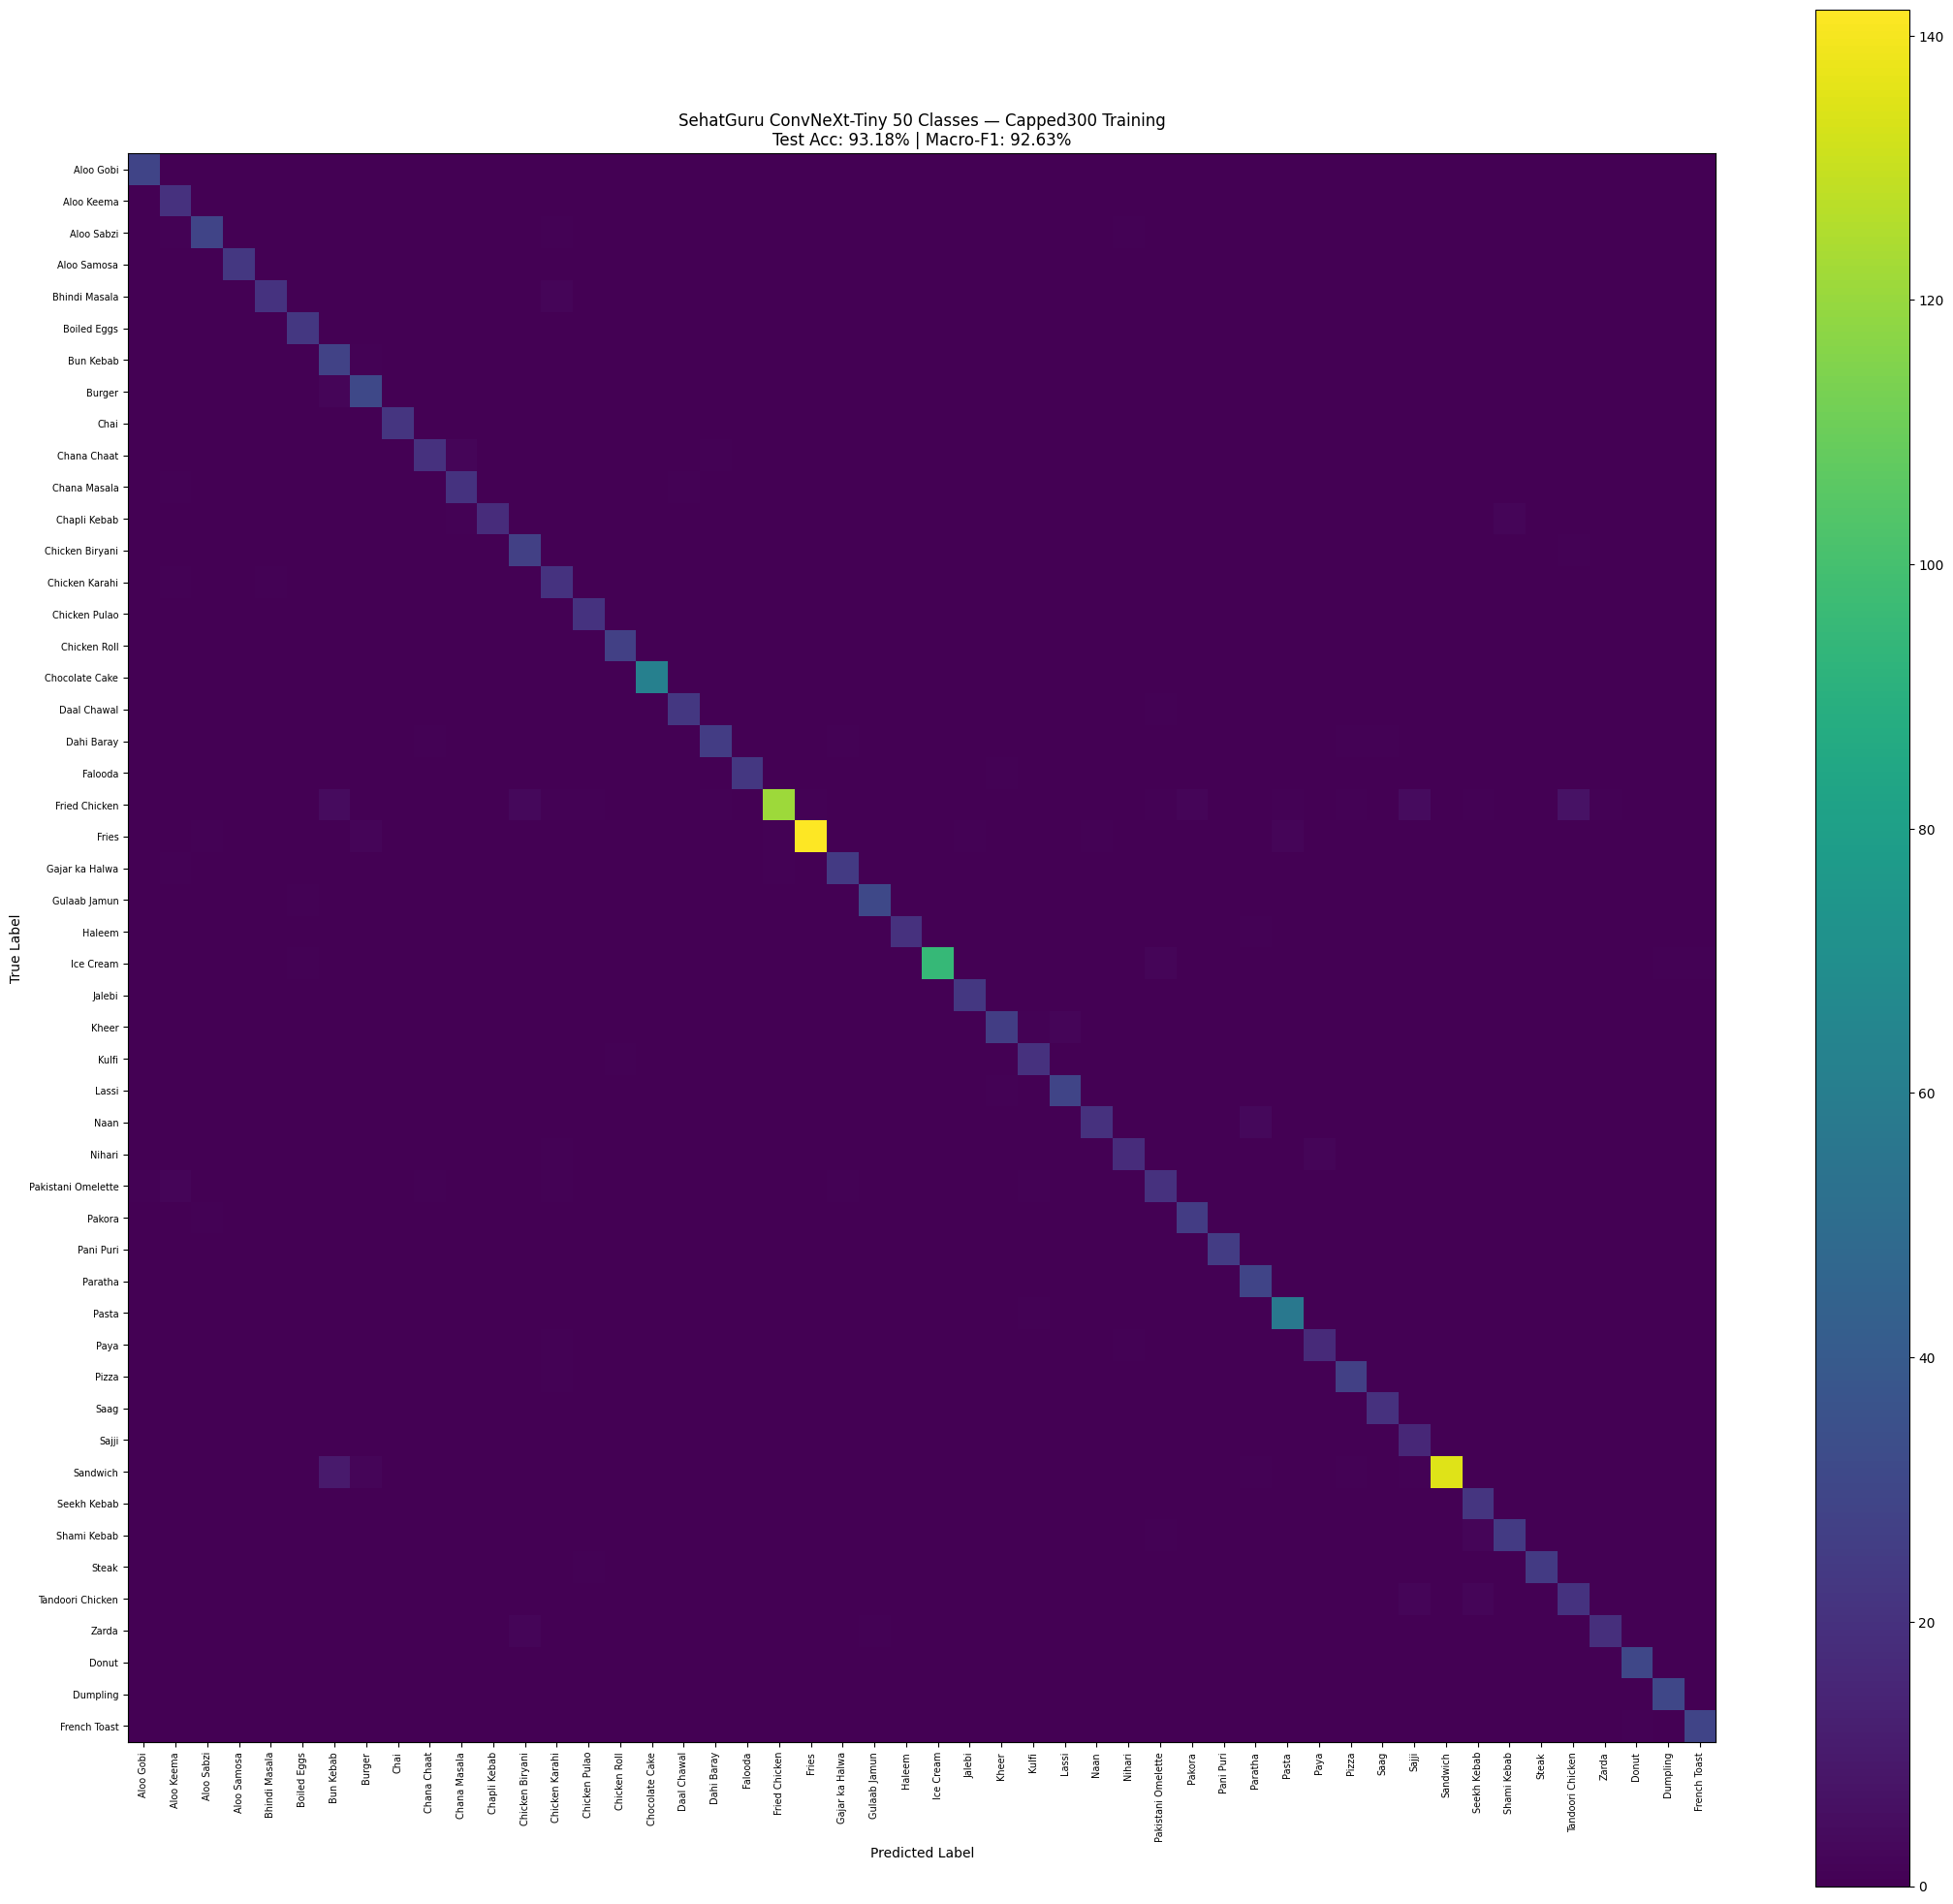

Saved confusion matrix: /kaggle/working/confusion_matrix_50_classes_capped300.png
Saved confidence report: /kaggle/working/confidence_report_50_classes_capped300.csv

Weakest classes by test accuracy/confidence:
              Dish  Samples  Accuracy  AvgConfidence  WrongCount
Pakistani Omelette       27 74.074074      70.839394           7
     Fried Chicken      150 80.666667      78.042259          29
  Tandoori Chicken       25 84.000000      83.284119           4
      Chapli Kebab       21 85.714286      78.279182           3
            Nihari       21 85.714286      86.293884           3
        Dahi Baray       29 86.206897      83.019104           4
             Zarda       22 86.363636      86.391960           3
       Chana Chaat       23 86.956522      85.205307           3
              Naan       23 86.956522      88.924484           3
       Shami Kebab       27 88.888889      91.595551           3
              Paya       19 89.473684      86.229584           2
        

In [10]:
##### ==================================================================================
# 13. FINAL TEST EVALUATION
# ==================================================================================

print("\n" + "=" * 90)
print("FINAL TEST EVALUATION — CAPPED TRAINING VERSION")
print("=" * 90)

final_model = ConvNeXtFoodModel(n_classes=n_classes).to(DEVICE)
best_ckpt = load_model_weights(FINAL_CKPT, final_model)

final_model.eval()

test_metrics = evaluate_model(
    final_model,
    test_loader,
    criterion=criterion,
    use_tta=True,
)

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
confidences = test_metrics["confidences"]

print(
    f"\nTest Acc: {test_metrics['acc']:.2f}% | "
    f"Test Macro-F1: {test_metrics['macro_f1']:.2f}% | "
    f"Test Weighted-F1: {test_metrics['weighted_f1']:.2f}%"
)

print("\nClassification Report:")

report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(REPORT_CSV)

print(f"Saved classification report: {REPORT_CSV}")


# ==================================================================================
# 14. CONFUSION MATRIX
# ==================================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(n_classes)),
)

plt.figure(figsize=(22, 20))
plt.imshow(cm, interpolation="nearest")
plt.title(
    f"SehatGuru ConvNeXt-Tiny 50 Classes — Capped300 Training\n"
    f"Test Acc: {test_metrics['acc']:.2f}% | Macro-F1: {test_metrics['macro_f1']:.2f}%"
)

plt.colorbar()

tick_marks = np.arange(n_classes)

plt.xticks(tick_marks, class_names, rotation=90, fontsize=7)
plt.yticks(tick_marks, class_names, fontsize=7)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

plt.savefig(CONFUSION_PNG, dpi=200)
plt.show()

print(f"Saved confusion matrix: {CONFUSION_PNG}")


# ==================================================================================
# 15. CONFIDENCE REPORT
# ==================================================================================

pred_df = pd.DataFrame({
    "true_id": y_true,
    "pred_id": y_pred,
    "confidence": confidences,
})

pred_df["true_label"] = pred_df["true_id"].apply(lambda x: class_names[x])
pred_df["pred_label"] = pred_df["pred_id"].apply(lambda x: class_names[x])
pred_df["correct"] = pred_df["true_id"] == pred_df["pred_id"]

stats = []

for class_id, dish in enumerate(class_names):
    dish_df = pred_df[pred_df["true_id"] == class_id]

    if len(dish_df) == 0:
        continue

    stats.append({
        "Dish": dish,
        "Samples": len(dish_df),
        "Accuracy": dish_df["correct"].mean() * 100,
        "AvgConfidence": dish_df["confidence"].mean() * 100,
        "WrongCount": int((~dish_df["correct"]).sum()),
    })

stats_df = pd.DataFrame(stats).sort_values(
    by=["Accuracy", "AvgConfidence"],
    ascending=[True, True],
)

stats_df.to_csv(CONFIDENCE_CSV, index=False)

print(f"Saved confidence report: {CONFIDENCE_CSV}")
print("\nWeakest classes by test accuracy/confidence:")
print(stats_df.head(15).to_string(index=False))


# ==================================================================================
# 16. HARD EXAMPLES EXPORT
# ==================================================================================

test_paths = [dataset.sample_paths[i] for i in test_idx]

pred_df["image_path"] = test_paths

hard_examples = pred_df[pred_df["correct"] == False].copy()
hard_examples = hard_examples.sort_values(
    by="confidence",
    ascending=False,
)

hard_examples.to_csv(HARD_EXAMPLES_CSV, index=False)

print(f"Saved hard examples: {HARD_EXAMPLES_CSV}")

print("\nMost confident wrong predictions:")

if len(hard_examples) > 0:
    print(
        hard_examples[
            ["image_path", "true_label", "pred_label", "confidence"]
        ].head(20).to_string(index=False)
    )
else:
    print("No wrong predictions in the test set.")


# ==================================================================================
# 17. CONFUSION PAIR ANALYSIS
# ==================================================================================

pairs = []

for true_id in range(n_classes):
    for pred_id in range(n_classes):
        if true_id == pred_id:
            continue

        count = cm[true_id, pred_id]

        if count > 0:
            pairs.append({
                "true_label": class_names[true_id],
                "predicted_as": class_names[pred_id],
                "count": int(count),
            })

pairs_df = pd.DataFrame(pairs)

if len(pairs_df) > 0:
    pairs_df = pairs_df.sort_values(
        by="count",
        ascending=False,
    )

    pairs_df.to_csv(CONFUSION_PAIRS_CSV, index=False)

    print(f"Saved confusion pairs: {CONFUSION_PAIRS_CSV}")
    print("\nTop confused dish pairs:")
    print(pairs_df.head(20).to_string(index=False))

else:
    pairs_df.to_csv(CONFUSION_PAIRS_CSV, index=False)
    print("No confusion pairs found.")


# ==================================================================================
# 18. ZIP OUTPUTS FOR DOWNLOAD
# ==================================================================================

print("\n" + "=" * 90)
print("ZIPPING OUTPUTS FOR DOWNLOAD")
print("=" * 90)

# Include cap report in output folder too
output_dir = "/kaggle/working/sehatguru_capped400_outputs"

shutil.rmtree(output_dir, ignore_errors=True)
os.makedirs(output_dir, exist_ok=True)

output_files = [
    FOOD101_CKPT,
    FINAL_CKPT,
    LAST_CKPT,
    CONFUSION_PNG,
    CONFIDENCE_CSV,
    REPORT_CSV,
    HARD_EXAMPLES_CSV,
    CONFUSION_PAIRS_CSV,
    SPLIT_JSON,
    TRAINING_HISTORY_CSV,
    cap_report_path,
]

for file_path in output_files:
    if os.path.exists(file_path):
        shutil.copy(file_path, output_dir)
        print("Copied:", os.path.basename(file_path))
    else:
        print("Missing:", file_path)

if os.path.exists(OUTPUT_ZIP):
    os.remove(OUTPUT_ZIP)

shutil.make_archive(
    OUTPUT_ZIP.replace(".zip", ""),
    "zip",
    output_dir,
)

print("\nCreated output zip:")
print(OUTPUT_ZIP)


# ==================================================================================
# 19. FINAL SUMMARY
# ==================================================================================

print("\n" + "=" * 90)
print("PIPELINE COMPLETE — CAPPED TRAINING VERSION")
print("=" * 90)

print("Best capped SehatGuru checkpoint:")
print(FINAL_CKPT)

print("\nFinal test results:")
print(f"Test Accuracy: {test_metrics['acc']:.2f}%")
print(f"Test Macro-F1: {test_metrics['macro_f1']:.2f}%")
print(f"Test Weighted-F1: {test_metrics['weighted_f1']:.2f}%")

print("\nDownload this zip from Kaggle output files:")
print(OUTPUT_ZIP)

print("\nImportant:")
print("Compare this capped model with your previous model:")
print("Previous model: Test Accuracy 94.25%, Macro-F1 92.97%, Weighted-F1 94.20%")
print("Use whichever model has better Macro-F1 and better weak-class performance.")
print("Use class_names stored inside the checkpoint during inference.")

Validation dataset checking

TRAINED CLASSES
00: Aloo Gobi
01: Aloo Keema
02: Aloo Sabzi
03: Aloo Samosa
04: Bhindi Masala
05: Boiled Eggs
06: Bun Kebab
07: Burger
08: Chai
09: Chana Chaat
10: Chana Masala
11: Chapli Kebab
12: Chicken Biryani
13: Chicken Karahi
14: Chicken Pulao
15: Chicken Roll
16: Chocolate Cake
17: Daal Chawal
18: Dahi Baray
19: Falooda
20: Fried Chicken
21: Fries
22: Gajar ka Halwa
23: Gulaab Jamun
24: Haleem
25: Ice Cream
26: Jalebi
27: Kheer
28: Kulfi
29: Lassi
30: Naan
31: Nihari
32: Pakistani Omelette
33: Pakora
34: Pani Puri
35: Paratha
36: Pasta
37: Paya
38: Pizza
39: Saag
40: Sajji
41: Sandwich
42: Seekh Kebab
43: Shami Kebab
44: Steak
45: Tandoori Chicken
46: Zarda
47: Donut
48: Dumpling
49: French Toast

Total trained classes: 50

VALIDATION CLASSES
00: Aloo Gobi
01: Aloo Keema
02: Aloo Sabzi
03: Aloo Samosa
04: Bhindi Masala
05: Boiled Eggs
06: Bun Kebab
07: Burger
08: Chai
09: Chana Chaat
10: Chana Masala
11: Chapli Kebab
12: Chicken Biryani
13: Chicken Karahi
14: Chicken Pulao
15: 

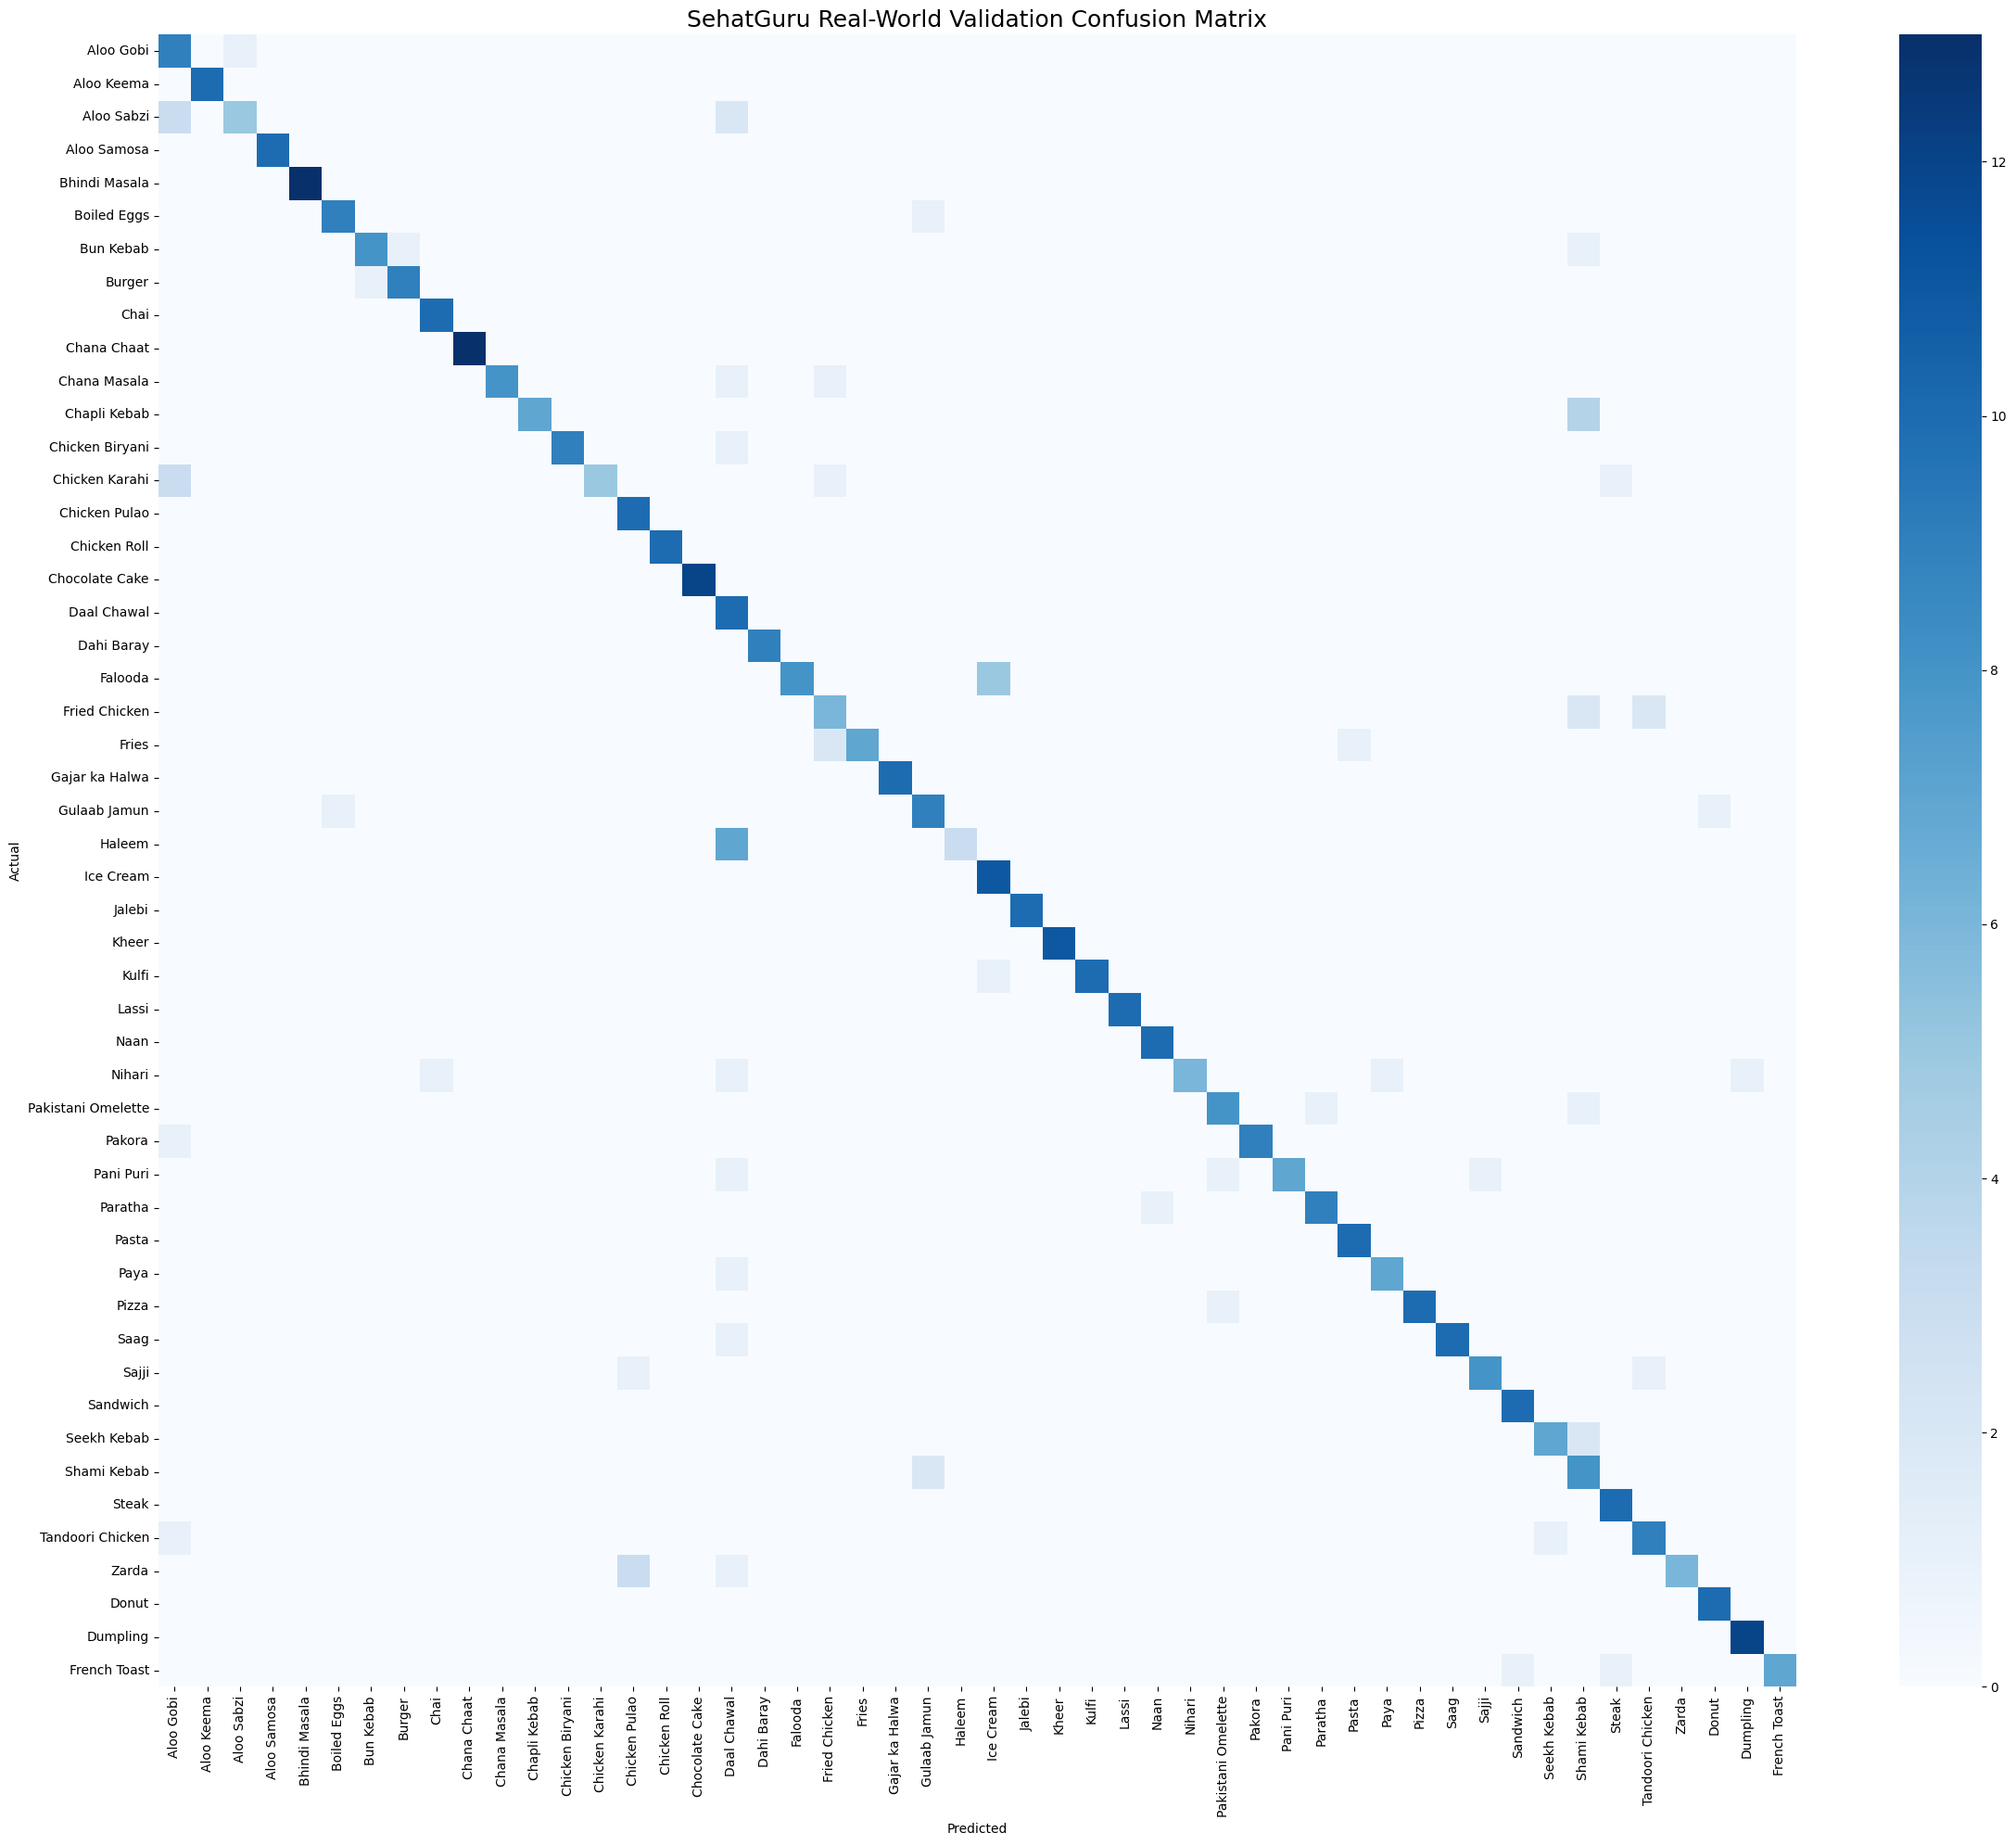


Lowest confidence predictions:
           true_class        pred_class  confidence  correct
358            Nihari          Dumpling    0.151421    False
99        Chana Chaat       Chana Chaat    0.162732     True
105       Chana Chaat       Chana Chaat    0.171010     True
423              Paya       Daal Chawal    0.186888    False
252             Fries     Fried Chicken    0.207149    False
483       Shami Kebab       Shami Kebab    0.210109     True
3           Aloo Gobi         Aloo Gobi    0.216038     True
140    Chicken Karahi             Steak    0.217228    False
484       Shami Kebab      Gulaab Jamun    0.225044    False
107      Chana Masala      Chana Masala    0.240132     True
258             Fries     Fried Chicken    0.248516    False
27         Aloo Sabzi        Aloo Sabzi    0.248776     True
360            Nihari            Nihari    0.250810     True
145    Chicken Karahi    Chicken Karahi    0.258359     True
129   Chicken Biryani   Chicken Biryani    0.264213  

In [14]:
# ==================================================================================
# SEHATGURU REAL-WORLD VALIDATION EVALUATION SCRIPT
# FINAL FIXED VERSION
# ==================================================================================

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import timm

# ==================================================================================
# CONFIG
# ==================================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 260

VAL_DIR = "/kaggle/input/datasets/ahtishamuwu/validation-50/validation"

CKPT_PATH = "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"

BATCH_SIZE = 32

# ==================================================================================
# TRAINED CLASS ORDER (MUST MATCH TRAINING EXACTLY)
# ==================================================================================

TRAIN_CLASSES = [
    "Aloo Gobi",
    "Aloo Keema",
    "Aloo Sabzi",
    "Aloo Samosa",
    "Bhindi Masala",
    "Boiled Eggs",
    "Bun Kebab",
    "Burger",
    "Chai",
    "Chana Chaat",
    "Chana Masala",
    "Chapli Kebab",
    "Chicken Biryani",
    "Chicken Karahi",
    "Chicken Pulao",
    "Chicken Roll",
    "Chocolate Cake",
    "Daal Chawal",
    "Dahi Baray",
    "Falooda",
    "Fried Chicken",
    "Fries",
    "Gajar ka Halwa",
    "Gulaab Jamun",
    "Haleem",
    "Ice Cream",
    "Jalebi",
    "Kheer",
    "Kulfi",
    "Lassi",
    "Naan",
    "Nihari",
    "Pakistani Omelette",
    "Pakora",
    "Pani Puri",
    "Paratha",
    "Pasta",
    "Paya",
    "Pizza",
    "Saag",
    "Sajji",
    "Sandwich",
    "Seekh Kebab",
    "Shami Kebab",
    "Steak",
    "Tandoori Chicken",
    "Zarda",
    "Donut",
    "Dumpling",
    "French Toast",
]


NUM_CLASSES = len(TRAIN_CLASSES)

print("=" * 90)
print("TRAINED CLASSES")
print("=" * 90)

for i, c in enumerate(TRAIN_CLASSES):
    print(f"{i:02d}: {c}")

print(f"\nTotal trained classes: {NUM_CLASSES}")

# ==================================================================================
# NORMALIZATION / CLASS NAME FIXING
# ==================================================================================

def normalize_name(name):

    n = name.strip().lower()

    mapping = {

        # biryani issue
        "biryani": "Chicken Biryani",

        # case fixes
        "gajar ka halwa": "Gajar ka Halwa",

        # donut fixes
        "donuts": "Donut",
        "donut": "Donut",

        # dumpling fixes
        "dumplings": "Dumpling",
        "dumpling": "Dumpling",
        
        "french toast": "French Toast",
        "french_toast": "French Toast",
        "french-toast": "French Toast",

        "bhindi": "Bhindi Masala",
        "bhindi masala": "Bhindi Masala",
        
        "boti roll": "Chicken Roll",
        "chicken roll": "Chicken Roll",

    }

    if n in mapping:
        return mapping[n]

    return " ".join([x.capitalize() for x in n.split()])


# ==================================================================================
# TRANSFORMS
# ==================================================================================

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225],
    ),
])

# ==================================================================================
# LOAD DATASET
# ==================================================================================

dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

# ==================================================================================
# FIX CLASS NAMES
# ==================================================================================

original_classes = dataset.classes

fixed_classes = [normalize_name(c) for c in original_classes]

print("\n" + "=" * 90)
print("VALIDATION CLASSES")
print("=" * 90)

for i, c in enumerate(fixed_classes):
    print(f"{i:02d}: {c}")

print(f"\nValidation classes: {len(fixed_classes)}")

# ==================================================================================
# CHECK CONSISTENCY
# ==================================================================================

trained_set = set(TRAIN_CLASSES)
validation_set = set(fixed_classes)

missing_in_validation = trained_set - validation_set
extra_in_validation = validation_set - trained_set

print("\n" + "=" * 90)
print("CLASS CONSISTENCY CHECK")
print("=" * 90)

print("Missing in validation:")
print(missing_in_validation)

print("\nExtra in validation:")
print(extra_in_validation)

if len(extra_in_validation) > 0:
    print(f"Ignoring validation classes not in trained model: {extra_in_validation}")


# ==================================================================================
# CREATE CLASS INDEX MAPPING
# ==================================================================================

train_class_to_idx = {
    c: i for i, c in enumerate(TRAIN_CLASSES)
}

# validation_idx_to_train_idx = {}

# for val_idx, val_class in enumerate(fixed_classes):
#     validation_idx_to_train_idx[val_idx] = train_class_to_idx[val_class]

# ==================================================================================
# REMAP DATASET TARGETS
# ==================================================================================

new_samples = []
ignored_count = 0

for path, target in dataset.samples:
    original_class = original_classes[target]
    fixed_class = normalize_name(original_class)

    if fixed_class not in train_class_to_idx:
        ignored_count += 1
        continue

    new_target = train_class_to_idx[fixed_class]
    new_samples.append((path, new_target))

dataset.samples = new_samples
dataset.imgs = new_samples
dataset.targets = [s[1] for s in new_samples]

print(f"Ignored images from removed/unknown classes: {ignored_count}")
print(f"Images used for evaluation: {len(dataset.samples)}")

# ==================================================================================
# DATALOADER
# ==================================================================================

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ==================================================================================
# MODEL
# ==================================================================================

class ConvNeXtFoodModel(nn.Module):

    def __init__(self, n_classes):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=False,
            num_classes=0,
            global_pool="avg",
        )

        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim, eps=1e-6),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):

        x = self.backbone(x)

        if x.ndim > 2:
            x = torch.flatten(x, 1)

        return self.head(x)

# ==================================================================================
# LOAD CHECKPOINT
# ==================================================================================

checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

print("\n" + "=" * 90)
print("CHECKPOINT INFO")
print("=" * 90)

print("Checkpoint keys:")
print(checkpoint.keys())

model = ConvNeXtFoodModel(NUM_CLASSES).to(DEVICE)

# IMPORTANT FIX
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("\nModel loaded successfully.")

# ==================================================================================
# EVALUATION
# ==================================================================================

y_true = []
y_pred = []
confidences = []

softmax = nn.Softmax(dim=1)

print("\nRunning evaluation...")

with torch.no_grad():

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        probs = softmax(outputs)

        preds = torch.argmax(probs, dim=1)

        conf = torch.max(probs, dim=1)[0]

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        confidences.extend(conf.cpu().numpy())

# ==================================================================================
# METRICS
# ==================================================================================

acc = accuracy_score(y_true, y_pred)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

avg_conf = np.mean(confidences)

print("\n" + "=" * 90)
print("FINAL RESULTS")
print("=" * 90)

print(f"Accuracy       : {acc:.4f}")
print(f"Macro F1       : {f1_macro:.4f}")
print(f"Weighted F1    : {f1_weighted:.4f}")
print(f"Avg Confidence : {avg_conf:.4f}")

# ==================================================================================
# CLASSIFICATION REPORT
# ==================================================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=TRAIN_CLASSES,
    digits=4,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(df_report)

df_report.to_csv(
    "/kaggle/working/classification_report_realworld.csv"
)

# ==================================================================================
# CONFUSION MATRIX
# ==================================================================================

print("\nGenerating confusion matrix...")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 20))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=TRAIN_CLASSES,
    yticklabels=TRAIN_CLASSES
)

plt.title(
    "SehatGuru Real-World Validation Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix_realworld.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ==================================================================================
# CONFIDENCE ANALYSIS
# ==================================================================================

df_conf = pd.DataFrame({
    "true_class": [TRAIN_CLASSES[x] for x in y_true],
    "pred_class": [TRAIN_CLASSES[x] for x in y_pred],
    "confidence": confidences
})

df_conf["correct"] = (
    df_conf["true_class"] == df_conf["pred_class"]
)

df_conf.to_csv(
    "/kaggle/working/confidence_analysis_realworld.csv",
    index=False
)

# ==================================================================================
# LOW CONFIDENCE SAMPLES
# ==================================================================================

print("\nLowest confidence predictions:")

print(
    df_conf.sort_values("confidence")
    .head(20)
)

# ==================================================================================
# WRONG PREDICTIONS
# ==================================================================================

wrong_df = df_conf[df_conf["correct"] == False]

print("\nTotal wrong predictions:", len(wrong_df))

if len(wrong_df) > 0:

    print("\nMost common mistakes:")

    print(
        wrong_df.groupby(
            ["true_class", "pred_class"]
        )
        .size()
        .sort_values(ascending=False)
        .head(20)
    )

# ==================================================================================
# SAVE SUMMARY
# ==================================================================================

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
        "Average Confidence"
    ],
    "Value": [
        acc,
        f1_macro,
        f1_weighted,
        avg_conf
    ]
})

summary.to_csv(
    "/kaggle/working/realworld_summary_metrics.csv",
    index=False
)

print("\n" + "=" * 90)
print("FILES SAVED")
print("=" * 90)

print("classification_report_realworld.csv")
print("confidence_analysis_realworld.csv")
print("confusion_matrix_realworld.png")
print("realworld_summary_metrics.csv")

print("\nEvaluation completed successfully.")

In [15]:
import torch

path1 = "/kaggle/working/sehatguru_capped400_outputs/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"
path2 = "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth"

ckpt1 = torch.load(path1, map_location="cpu")
ckpt2 = torch.load(path2, map_location="cpu")

print("PATH 1")
print("Best Macro F1:", ckpt1.get("best_macro_f1"))
print("Created:", ckpt1.get("created_at"))

print("\nPATH 2")
print("Best Macro F1:", ckpt2.get("best_macro_f1"))
print("Created:", ckpt2.get("created_at"))

PATH 1
Best Macro F1: 93.64809691370021
Created: 2026-05-14 12:55:22

PATH 2
Best Macro F1: 93.64809691370021
Created: 2026-05-14 12:55:22


run this to download the zip file if it doesnt donwload from outputs

In [ ]:
from IPython.display import FileLink, display
import os

zip_path = "/kaggle/working/sehatguru_50_capped300_training_outputs.zip"

print("Exists:", os.path.exists(zip_path))
print("Size MB:", os.path.getsize(zip_path) / (1024 * 1024) if os.path.exists(zip_path) else "missing")

display(FileLink("sehatguru_50_capped300_training_outputs.zip"))

image distribution per class 

In [ ]:
# ==================================================================================
# IMAGE DISTRIBUTION PER CLASS AFTER CAPPING TO 300 — SEHATGURU 50 DATASET
# ==================================================================================

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATASET_DIR = "/kaggle/input/datasets/ahtishamuwu/sehatguru-dishes-50/50_dishes_dataset"

CAP_PER_CLASS = 300

OUTPUT_CSV = "/kaggle/working/class_image_distribution_capped300.csv"
OUTPUT_PNG = "/kaggle/working/class_image_distribution_capped300.png"
OUTPUT_COMPARE_PNG = "/kaggle/working/class_image_distribution_original_vs_capped300.png"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Check dataset path
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Dataset not found at: {DATASET_DIR}")

class_counts = []

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = Path(DATASET_DIR) / class_name

    if not class_path.is_dir():
        continue

    image_files = [
        file for file in class_path.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    original_count = len(image_files)
    capped_count = min(original_count, CAP_PER_CLASS)

    class_counts.append({
        "class_name": class_name,
        "original_image_count": original_count,
        "capped_image_count": capped_count,
        "removed_by_cap": original_count - capped_count
    })

df = pd.DataFrame(class_counts)

# Sort by capped count first, then original count
df = df.sort_values(
    by=["capped_image_count", "original_image_count"],
    ascending=[False, False]
).reset_index(drop=True)

# Save CSV
df.to_csv(OUTPUT_CSV, index=False)

print("=" * 90)
print("CLASS IMAGE DISTRIBUTION AFTER CAPPING TO 300")
print("=" * 90)

print(df.to_string(index=False))

print("\nSummary After Capping:")
print(f"Total classes: {len(df)}")
print(f"Original total images: {df['original_image_count'].sum()}")
print(f"Capped total images: {df['capped_image_count'].sum()}")
print(f"Total images removed by cap: {df['removed_by_cap'].sum()}")
print(f"Minimum capped images in a class: {df['capped_image_count'].min()}")
print(f"Maximum capped images in a class: {df['capped_image_count'].max()}")
print(f"Mean capped images per class: {df['capped_image_count'].mean():.2f}")
print(f"Median capped images per class: {df['capped_image_count'].median():.2f}")

print("\nSaved CSV:")
print(OUTPUT_CSV)

# ==================================================================================
# Plot 1: Capped distribution only
# ==================================================================================

plt.figure(figsize=(18, 10))

plt.bar(df["class_name"], df["capped_image_count"])

plt.title("Image Distribution per Class After Capping at 300 — SehatGuru 50 Classes", fontsize=16)
plt.xlabel("Food Class", fontsize=12)
plt.ylabel("Number of Images After Cap", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()

plt.savefig(OUTPUT_PNG, dpi=200)
plt.show()

print("\nSaved capped chart:")
print(OUTPUT_PNG)


# ==================================================================================
# Plot 2: Original vs capped comparison
# ==================================================================================

df_compare = df.sort_values(by="original_image_count", ascending=False).reset_index(drop=True)

x = range(len(df_compare))
width = 0.4

plt.figure(figsize=(20, 10))

plt.bar(
    [i - width / 2 for i in x],
    df_compare["original_image_count"],
    width=width,
    label="Original"
)

plt.bar(
    [i + width / 2 for i in x],
    df_compare["capped_image_count"],
    width=width,
    label="Capped at 300"
)

plt.title("Original vs Capped Image Distribution — SehatGuru 50 Classes", fontsize=16)
plt.xlabel("Food Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(x, df_compare["class_name"], rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_COMPARE_PNG, dpi=200)
plt.show()

print("\nSaved original vs capped comparison chart:")
print(OUTPUT_COMPARE_PNG)

## Additional Architecture Experiments

These cells run CoAtNet and ConvNeXtV2-Base as separate experiments using the already prepared SehatGuru splits. Each experiment writes its own checkpoints and reports under `/kaggle/working`, so it will not overwrite the ConvNeXt-Tiny run above.


In [23]:
# ==================================================================================
# EXTRA ARCHITECTURE EXPERIMENT HELPERS
# CoAtNet + ConvNeXtV2-Base separate runs
# ==================================================================================

# Preserve original split indices because some later validation cells may reuse names like val_idx.
TRAIN_SPLIT_IDX = list(train_idx)
VAL_SPLIT_IDX = list(val_idx)
TEST_SPLIT_IDX = list(test_idx)


class GenericFoodVisionModel(nn.Module):
    def __init__(self, n_classes, backbone_name, pretrained=True):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )
        feature_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def reset_classes(self, n_classes):
        feature_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        if features.ndim > 2:
            features = torch.flatten(features, 1)
        return self.head(features)


def assert_timm_model_available(backbone_name):
    available = timm.list_models(backbone_name)
    if available:
        return

    family = backbone_name.split(".")[0].split("_")[0]
    suggestions = timm.list_models(f"*{family}*")[:30]
    raise ValueError(
        f"timm model '{backbone_name}' was not found. "
        f"Try one of these or run timm.list_models('*{family}*'): {suggestions}"
    )


def make_experiment_paths(model_tag):
    return {
        "food101_ckpt": f"/kaggle/working/stage1_food101_{model_tag}.pth",
        "final_ckpt": f"/kaggle/working/SehatGuru_{model_tag}_best_macroF1.pth",
        "last_ckpt": f"/kaggle/working/SehatGuru_{model_tag}_last.pth",
        "confusion_png": f"/kaggle/working/confusion_matrix_{model_tag}.png",
        "confidence_csv": f"/kaggle/working/confidence_report_{model_tag}.csv",
        "report_csv": f"/kaggle/working/classification_report_{model_tag}.csv",
        "hard_examples_csv": f"/kaggle/working/hard_examples_{model_tag}.csv",
        "confusion_pairs_csv": f"/kaggle/working/top_confusion_pairs_{model_tag}.csv",
        "history_csv": f"/kaggle/working/training_history_{model_tag}.csv",
        "summary_csv": f"/kaggle/working/summary_metrics_{model_tag}.csv",
        "output_zip": f"/kaggle/working/sehatguru_{model_tag}_outputs.zip",
    }


def build_loaders_for_img_size(img_size, batch_size):
    global IMG_SIZE
    old_img_size = IMG_SIZE
    IMG_SIZE = img_size

    exp_train_transform = build_train_transform()
    exp_val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])

    exp_train_data = TransformedSubset(dataset, TRAIN_SPLIT_IDX, exp_train_transform)
    exp_val_data = TransformedSubset(dataset, VAL_SPLIT_IDX, exp_val_transform)
    exp_test_data = TransformedSubset(dataset, TEST_SPLIT_IDX, exp_val_transform)

    exp_train_loader = DataLoader(
        exp_train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    exp_val_loader = DataLoader(
        exp_val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    exp_test_loader = DataLoader(
        exp_test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    IMG_SIZE = old_img_size

    return (
        exp_train_loader,
        exp_val_loader,
        exp_test_loader,
        exp_train_transform,
        exp_val_transform,
    )



def repair_checkpoint_metadata(path, architecture_name, img_size, model_tag):
    try:
        ckpt = torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location="cpu")

    if isinstance(ckpt, dict):
        ckpt["architecture"] = architecture_name
        ckpt["backbone_name"] = architecture_name
        ckpt["img_size"] = img_size
        ckpt["model_tag"] = model_tag
        torch.save(ckpt, path)


def save_architecture_reports(model_tag, paths, test_metrics, class_names):
    y_true = test_metrics["y_true"]
    y_pred = test_metrics["y_pred"]
    confidences = test_metrics["confidences"]

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report_dict).transpose().to_csv(paths["report_csv"])

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 20))
    plt.imshow(cm, interpolation="nearest")
    plt.title(
        f"SehatGuru {model_tag} 50 Classes\n"
        f"Test Acc: {test_metrics['acc']:.2f}% | Macro-F1: {test_metrics['macro_f1']:.2f}%"
    )
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=7)
    plt.yticks(tick_marks, class_names, fontsize=7)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(paths["confusion_png"], dpi=250)
    plt.close()

    conf_df = pd.DataFrame({
        "true_label": [class_names[i] for i in y_true],
        "pred_label": [class_names[i] for i in y_pred],
        "confidence": confidences,
    })
    conf_df["correct"] = conf_df["true_label"] == conf_df["pred_label"]
    conf_df.to_csv(paths["confidence_csv"], index=False)

    hard_df = conf_df[conf_df["correct"] == False].sort_values("confidence", ascending=False)
    hard_df.to_csv(paths["hard_examples_csv"], index=False)

    if len(hard_df) > 0:
        pairs_df = (
            hard_df.groupby(["true_label", "pred_label"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
    else:
        pairs_df = pd.DataFrame(columns=["true_label", "pred_label", "count"])
    pairs_df.to_csv(paths["confusion_pairs_csv"], index=False)

    summary_df = pd.DataFrame([
        {
            "model_tag": model_tag,
            "accuracy": test_metrics["acc"],
            "macro_f1": test_metrics["macro_f1"],
            "weighted_f1": test_metrics["weighted_f1"],
            "avg_confidence": float(np.mean(confidences)) if len(confidences) else 0.0,
        }
    ])
    summary_df.to_csv(paths["summary_csv"], index=False)


def zip_architecture_outputs(paths):
    output_dir = paths["output_zip"].replace(".zip", "")
    os.makedirs(output_dir, exist_ok=True)

    for file_path in paths.values():
        if file_path.endswith(".zip"):
            continue
        if os.path.exists(file_path):
            shutil.copy(file_path, output_dir)
        else:
            print("Missing:", file_path)

    if os.path.exists(paths["output_zip"]):
        os.remove(paths["output_zip"])

    shutil.make_archive(paths["output_zip"].replace(".zip", ""), "zip", output_dir)
    print("Created output zip:", paths["output_zip"])


def run_architecture_experiment(
    model_tag,
    backbone_name,
    img_size,
    batch_size,
    run_food101_pretraining=True,
):
    global IMG_SIZE

    assert_timm_model_available(backbone_name)
    paths = make_experiment_paths(model_tag)

    print("\n" + "=" * 90)
    print(f"STARTING ARCHITECTURE EXPERIMENT: {model_tag}")
    print("=" * 90)
    print("Backbone:", backbone_name)
    print("Image size:", img_size)
    print("Batch size:", batch_size)
    print("Food-101 pretraining:", run_food101_pretraining)

    old_img_size = IMG_SIZE
    IMG_SIZE = img_size

    exp_train_loader, exp_val_loader, exp_test_loader, exp_train_transform, exp_val_transform = build_loaders_for_img_size(
        img_size=img_size,
        batch_size=batch_size,
    )

    model_exp = GenericFoodVisionModel(
        n_classes=101 if run_food101_pretraining else n_classes,
        backbone_name=backbone_name,
        pretrained=True,
    ).to(DEVICE)

    history_frames = []

    if run_food101_pretraining:
        if REUSE_FOOD101_CKPT_IF_EXISTS and os.path.exists(paths["food101_ckpt"]):
            print("Reusing Food-101 checkpoint:", paths["food101_ckpt"])
            load_model_weights(paths["food101_ckpt"], model_exp)
        else:
            print("Loading Food-101 for", model_tag)
            food101_train = datasets.Food101(
                root=FOOD101_ROOT,
                split="train",
                transform=exp_train_transform,
                download=True,
            )
            food101_val = datasets.Food101(
                root=FOOD101_ROOT,
                split="test",
                transform=exp_val_transform,
                download=True,
            )
            food101_train_loader = DataLoader(
                food101_train,
                batch_size=batch_size,
                shuffle=True,
                num_workers=NUM_WORKERS,
                pin_memory=True,
            )
            food101_val_loader = DataLoader(
                food101_val,
                batch_size=batch_size,
                shuffle=False,
                num_workers=NUM_WORKERS,
                pin_memory=True,
            )
            food101_phases = [
                {
                    "name": "food101_full",
                    "epochs": FOOD101_EPOCHS,
                    "mode": "all",
                    "backbone_lr": 5e-5,
                    "head_lr": 1e-4,
                }
            ]
            food101_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
            _, food101_history = train_in_phases(
                model=model_exp,
                train_loader=food101_train_loader,
                val_loader=food101_val_loader,
                phases=food101_phases,
                criterion=food101_criterion,
                save_path=paths["food101_ckpt"],
                class_names=food101_train.classes,
                stage_name=f"Food-101-{model_tag}",
                use_mixup_cutmix=True,
                use_ema=USE_EMA,
            )
            repair_checkpoint_metadata(paths["food101_ckpt"], backbone_name, img_size, model_tag)
            load_model_weights(paths["food101_ckpt"], model_exp)
            history_frames.append(food101_history)

        model_exp.reset_classes(n_classes)
        model_exp = model_exp.to(DEVICE)

    class_weights_exp, _ = make_class_weights_from_labels(labels, train_idx, n_classes)
    if USE_FOCAL_LOSS:
        criterion_exp = FocalLoss(alpha=class_weights_exp.to(DEVICE), gamma=1.5)
    else:
        criterion_exp = nn.CrossEntropyLoss(
            weight=class_weights_exp.to(DEVICE),
            label_smoothing=0.05,
        )

    best_f1, history_df = train_in_phases(
        model=model_exp,
        train_loader=exp_train_loader,
        val_loader=exp_val_loader,
        phases=PHASES,
        criterion=criterion_exp,
        save_path=paths["final_ckpt"],
        class_names=class_names,
        stage_name=f"SehatGuru-50-{model_tag}",
        use_mixup_cutmix=USE_MIXUP_CUTMIX,
        use_ema=USE_EMA,
    )
    repair_checkpoint_metadata(paths["final_ckpt"], backbone_name, img_size, model_tag)
    history_frames.append(history_df)

    save_checkpoint(
        paths["last_ckpt"],
        model_exp,
        class_names=class_names,
        img_size=img_size,
        architecture=backbone_name,
        extra={
            "model_tag": model_tag,
            "backbone_name": backbone_name,
            "note": "last non-EMA model at end of architecture experiment",
            "dataset_root": DATASET_DIR,
            "train_cap_per_class": TRAIN_CAP_PER_CLASS,
            "removed_main_classes": list(REMOVE_MAIN_CLASSES),
            "extra_food101_classes": [x["display_name"] for x in EXTRA_FOOD101_CLASS_SPECS],
        },
    )

    if history_frames:
        pd.concat(history_frames, ignore_index=True).to_csv(paths["history_csv"], index=False)

    final_model_exp = GenericFoodVisionModel(
        n_classes=n_classes,
        backbone_name=backbone_name,
        pretrained=False,
    ).to(DEVICE)
    load_model_weights(paths["final_ckpt"], final_model_exp)
    final_model_exp.eval()

    test_metrics_exp = evaluate_model(
        final_model_exp,
        exp_test_loader,
        criterion=criterion_exp,
        use_tta=True,
    )

    print(
        f"\n{model_tag} Test Acc: {test_metrics_exp['acc']:.2f}% | "
        f"Macro-F1: {test_metrics_exp['macro_f1']:.2f}% | "
        f"Weighted-F1: {test_metrics_exp['weighted_f1']:.2f}%"
    )

    save_architecture_reports(model_tag, paths, test_metrics_exp, class_names)
    zip_architecture_outputs(paths)

    IMG_SIZE = old_img_size

    return {
        "model_tag": model_tag,
        "backbone_name": backbone_name,
        "best_val_macro_f1": best_f1,
        "test_metrics": test_metrics_exp,
        "paths": paths,
    }


In [24]:
# ==================================================================================
# RUN EXTRA MODEL 1: CoAtNet
# ==================================================================================

# If this exact timm name is unavailable in Kaggle, run:
# timm.list_models("*coatnet*")
# and replace COATNET_BACKBONE with the closest available CoAtNet model.

COATNET_RESULT = run_architecture_experiment(
    model_tag="coatnet0",
    backbone_name="coatnet_0_rw_224",
    img_size=224,
    batch_size=8,
    run_food101_pretraining=True,
)



STARTING ARCHITECTURE EXPERIMENT: coatnet0
Backbone: coatnet_0_rw_224
Image size: 224
Batch size: 8
Food-101 pretraining: True

Using TrivialAugmentWide.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading Food-101 for coatnet0

------------------------------------------------------------------------------------------
Food-101-coatnet0 | Phase: food101_full | Mode: all
------------------------------------------------------------------------------------------
Food-101-coatnet0 | Epoch 001 | Batch 0/9469 | Loss: 4.6409
Food-101-coatnet0 | Epoch 001 | Batch 100/9469 | Loss: 4.5386
Food-101-coatnet0 | Epoch 001 | Batch 200/9469 | Loss: 4.3183
Food-101-coatnet0 | Epoch 001 | Batch 300/9469 | Loss: 4.3062
Food-101-coatnet0 | Epoch 001 | Batch 400/9469 | Loss: 3.8408
Food-101-coatnet0 | Epoch 001 | Batch 500/9469 | Loss: 4.6760
Food-101-coatnet0 | Epoch 001 | Batch 600/9469 | Loss: 3.9380
Food-101-coatnet0 | Epoch 001 | Batch 700/9469 | Loss: 3.7502
Food-101-coatnet0 | Epoch 001 | Batch 800/9469 | Loss: 2.5975
Food-101-coatnet0 | Epoch 001 | Batch 900/9469 | Loss: 3.2489
Food-101-coatnet0 | Epoch 001 | Batch 1000/9469 | Loss: 3.6547
Food-101-coatnet0 | Epoch 001 | Batch 1100/9469 | Loss

In [39]:
# ==================================================================================
# RUN EXTRA MODEL 2: ConvNeXtV2-Base
# ==================================================================================

# If this exact timm name is unavailable in Kaggle, run:
# timm.list_models("*convnextv2_base*")
# and replace the backbone_name with the available ConvNeXtV2-Base checkpoint.

CONVNEXTV2_BASE_RESULT = run_architecture_experiment(
    model_tag="convnextv2_base",
    backbone_name="convnextv2_base",
    img_size=260,
    batch_size=8,
    run_food101_pretraining=True,
)




STARTING ARCHITECTURE EXPERIMENT: convnextv2_base
Backbone: convnextv2_base
Image size: 260
Batch size: 8
Food-101 pretraining: True

Using TrivialAugmentWide.
Loading Food-101 for convnextv2_base

------------------------------------------------------------------------------------------
Food-101-convnextv2_base | Phase: food101_full | Mode: all
------------------------------------------------------------------------------------------
Food-101-convnextv2_base | Epoch 001 | Batch 0/9469 | Loss: 4.7166
Food-101-convnextv2_base | Epoch 001 | Batch 100/9469 | Loss: 4.1596
Food-101-convnextv2_base | Epoch 001 | Batch 200/9469 | Loss: 2.9396
Food-101-convnextv2_base | Epoch 001 | Batch 300/9469 | Loss: 2.7778
Food-101-convnextv2_base | Epoch 001 | Batch 400/9469 | Loss: 2.1949
Food-101-convnextv2_base | Epoch 001 | Batch 500/9469 | Loss: 2.9950
Food-101-convnextv2_base | Epoch 001 | Batch 600/9469 | Loss: 1.6605
Food-101-convnextv2_base | Epoch 001 | Batch 700/9469 | Loss: 2.2628
Food-101-c

In [35]:
# ==================================================================================
# COMPARE EXTRA MODEL RESULTS
# ==================================================================================

extra_results = []
for result_name in ["COATNET_RESULT", "CONVNEXTV2_BASE_RESULT"]:
    if result_name in globals():
        result = globals()[result_name]
        metrics = result["test_metrics"]
        extra_results.append({
            "model_tag": result["model_tag"],
            "backbone_name": result["backbone_name"],
            "best_val_macro_f1": result["best_val_macro_f1"],
            "test_accuracy": metrics["acc"],
            "test_macro_f1": metrics["macro_f1"],
            "test_weighted_f1": metrics["weighted_f1"],
            "checkpoint": result["paths"]["final_ckpt"],
            "output_zip": result["paths"]["output_zip"],
        })

extra_results_df = pd.DataFrame(extra_results)
extra_results_df.to_csv("/kaggle/working/architecture_comparison_extra_models.csv", index=False)
extra_results_df


,model_tag,backbone_name,best_val_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,checkpoint,output_zip
0,coatnet0,coatnet_0_rw_224,91.445139,90.642616,90.457375,90.693281,/kaggle/working/SehatGuru_coatnet0_best_macroF...,/kaggle/working/sehatguru_coatnet0_outputs.zip


## Real-World Validation For Trained Architectures

Run these cells after a model checkpoint is created. They evaluate the checkpoint on your real-world validation folder, ignore removed/unknown folders, save per-model reports, and create a comparison CSV.


In [32]:
# ==================================================================================
# REAL-WORLD VALIDATION CONFIG
# ==================================================================================

# Change this if Kaggle mounts your dataset under a different slug.
REALWORLD_VAL_DIR = "/kaggle/input/datasets/ahtishamuwu/validation-50/validation"
REALWORLD_BATCH_SIZE = 32
REALWORLD_LOW_CONF_THRESHOLD = 0.60

# Candidate checkpoints. The cell below skips any checkpoint that does not exist yet.
REALWORLD_MODEL_SPECS = [
    {
        "model_tag": "convnext_tiny",
        "backbone_name": "convnext_tiny",
        "ckpt_path": "/kaggle/working/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth",
        "img_size": 260,
    },
    {
        "model_tag": "coatnet0",
        "backbone_name": "coatnet_0_rw_224.sw_in1k",
        "ckpt_path": "/kaggle/working/SehatGuru_coatnet0_best_macroF1.pth",
        "img_size": 224,
    },
    {
        "model_tag": "convnextv2_base",
        "backbone_name": "convnextv2_base.fcmae_ft_in22k_in1k",
        "ckpt_path": "/kaggle/working/SehatGuru_convnextv2_base_best_macroF1.pth",
        "img_size": 260,
    },
]


In [33]:
# ==================================================================================
# REAL-WORLD VALIDATION HELPERS
# ==================================================================================

import re
from PIL import Image, ImageOps

REALWORLD_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def normalize_realworld_folder_name(name):
    raw = str(name).strip()
    raw = re.sub(r"^\d+[_\-\s]*", "", raw)
    normalized = raw.lower().replace("_", " ").replace("-", " ").strip()
    normalized = " ".join(normalized.split())

    aliases = {
        "biryani": "Chicken Biryani",
        "chicken biryani": "Chicken Biryani",
        "bhindi": "Bhindi Masala",
        "bhindi masala": "Bhindi Masala",
        "boti roll": "Chicken Roll",
        "chicken roll": "Chicken Roll",
        "gajar ka halwa": "Gajar ka Halwa",
        "gulab jamun": "Gulaab Jamun",
        "gulaab jamun": "Gulaab Jamun",
        "pakistani omelet": "Pakistani Omelette",
        "pakistani omelette": "Pakistani Omelette",
        "pani puri": "Pani Puri",
        "seekh kabab": "Seekh Kebab",
        "seekh kebab": "Seekh Kebab",
        "shami kabab": "Shami Kebab",
        "shami kebab": "Shami Kebab",
        "tandoori chicken": "Tandoori Chicken",
        "donut": "Donut",
        "donuts": "Donut",
        "doughnut": "Donut",
        "doughnuts": "Donut",
        "dumpling": "Dumpling",
        "dumplings": "Dumpling",
        "french toast": "French Toast",
    }

    if normalized in aliases:
        return aliases[normalized]

    return " ".join(part.capitalize() for part in normalized.split())


class RealWorldValidationDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples = list(samples)
        self.transform = transform
        self.targets = [label for _, label, _ in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label, _ = self.samples[idx]
        image = Image.open(image_path)
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = self.transform(image)
        return image, label


def build_realworld_validation_dataset(val_dir, class_names, img_size):
    val_dir = Path(val_dir)
    if not val_dir.exists():
        raise FileNotFoundError(f"Real-world validation folder not found: {val_dir}")

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    samples = []
    ignored_folders = {}

    for class_dir in sorted(path for path in val_dir.iterdir() if path.is_dir()):
        fixed_class = normalize_realworld_folder_name(class_dir.name)
        if fixed_class not in class_to_idx:
            ignored_folders[class_dir.name] = fixed_class
            continue

        label = class_to_idx[fixed_class]
        for image_path in sorted(class_dir.rglob("*")):
            if image_path.is_file() and image_path.suffix.lower() in REALWORLD_IMAGE_EXTENSIONS:
                samples.append((str(image_path), label, fixed_class))

    transform = transforms.Compose([
        transforms.Resize((img_size + 32, img_size + 32)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225],
        ),
    ])

    dataset = RealWorldValidationDataset(samples, transform)
    return dataset, ignored_folders


def load_checkpoint_safely(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def evaluate_checkpoint_on_realworld(
    model_tag,
    backbone_name,
    ckpt_path,
    img_size,
    val_dir=REALWORLD_VAL_DIR,
    batch_size=REALWORLD_BATCH_SIZE,
):
    if "GenericFoodVisionModel" not in globals():
        raise RuntimeError("Run the extra architecture helper cell first so GenericFoodVisionModel exists.")

    ckpt_path = str(ckpt_path)
    if not os.path.exists(ckpt_path):
        print(f"Skipping {model_tag}; checkpoint not found: {ckpt_path}")
        return None

    checkpoint = load_checkpoint_safely(ckpt_path)
    class_names_from_ckpt = checkpoint.get("class_names") if isinstance(checkpoint, dict) else None
    if not class_names_from_ckpt:
        class_names_from_ckpt = class_names
    class_names_from_ckpt = [str(name) for name in class_names_from_ckpt]

    print("\n" + "=" * 90)
    print(f"REAL-WORLD VALIDATION: {model_tag}")
    print("=" * 90)
    print("Checkpoint:", ckpt_path)
    print("Backbone:", backbone_name)
    print("Classes:", len(class_names_from_ckpt))
    print("Validation dir:", val_dir)

    val_dataset, ignored_folders = build_realworld_validation_dataset(
        val_dir=val_dir,
        class_names=class_names_from_ckpt,
        img_size=img_size,
    )

    if ignored_folders:
        print("Ignored folders not in this checkpoint:")
        for original, normalized in ignored_folders.items():
            print(f"  {original} -> {normalized}")

    if len(val_dataset) == 0:
        raise ValueError("No usable real-world validation images found after filtering folders.")

    print("Images used:", len(val_dataset))

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model_eval = GenericFoodVisionModel(
        n_classes=len(class_names_from_ckpt),
        backbone_name=backbone_name,
        pretrained=False,
    ).to(DEVICE)

    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model_eval.load_state_dict(state_dict)
    model_eval.eval()

    y_true = []
    y_pred = []
    confidences = []
    top3_hits = 0
    top5_hits = 0
    rows = []
    sample_cursor = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model_eval(images)
            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, dim=1)
            topk_values, topk_indices = torch.topk(probs, k=min(5, len(class_names_from_ckpt)), dim=1)

            batch_size_actual = labels.size(0)
            for row_idx in range(batch_size_actual):
                image_path, _, expected_name = val_dataset.samples[sample_cursor]
                sample_cursor += 1

                true_idx = int(labels[row_idx].item())
                pred_idx = int(preds[row_idx].item())
                top_indices = [int(x) for x in topk_indices[row_idx].detach().cpu().tolist()]
                top_values = [float(x) for x in topk_values[row_idx].detach().cpu().tolist()]

                top3_hits += int(true_idx in top_indices[:3])
                top5_hits += int(true_idx in top_indices[:5])

                y_true.append(true_idx)
                y_pred.append(pred_idx)
                confidences.append(float(conf[row_idx].item()))

                rows.append({
                    "image": image_path,
                    "true_class": class_names_from_ckpt[true_idx],
                    "pred_class": class_names_from_ckpt[pred_idx],
                    "confidence": float(conf[row_idx].item()),
                    "correct": true_idx == pred_idx,
                    "low_confidence": float(conf[row_idx].item()) < REALWORLD_LOW_CONF_THRESHOLD,
                    "top3_correct": true_idx in top_indices[:3],
                    "top5_correct": true_idx in top_indices[:5],
                    "top5": " | ".join(
                        f"{class_names_from_ckpt[i]}:{v:.4f}"
                        for i, v in zip(top_indices, top_values)
                    ),
                })

    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    top3_acc = top3_hits / len(y_true) * 100
    top5_acc = top5_hits / len(y_true) * 100
    avg_conf = float(np.mean(confidences)) if confidences else 0.0
    low_conf_count = sum(float(c) < REALWORLD_LOW_CONF_THRESHOLD for c in confidences)

    print(f"Accuracy       : {acc:.2f}%")
    print(f"Top-3 Accuracy : {top3_acc:.2f}%")
    print(f"Top-5 Accuracy : {top5_acc:.2f}%")
    print(f"Macro F1       : {macro_f1:.2f}%")
    print(f"Weighted F1    : {weighted_f1:.2f}%")
    print(f"Avg Confidence : {avg_conf:.4f}")
    print(f"Low Confidence : {low_conf_count}")

    prefix = f"/kaggle/working/realworld_{model_tag}"
    rows_df = pd.DataFrame(rows)
    rows_df.to_csv(f"{prefix}_predictions.csv", index=False)

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names_from_ckpt))),
        target_names=class_names_from_ckpt,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report_dict).transpose().to_csv(f"{prefix}_classification_report.csv")

    wrong_df = rows_df[rows_df["correct"] == False]
    if len(wrong_df) > 0:
        pairs_df = (
            wrong_df.groupby(["true_class", "pred_class"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
    else:
        pairs_df = pd.DataFrame(columns=["true_class", "pred_class", "count"])
    pairs_df.to_csv(f"{prefix}_confusion_pairs.csv", index=False)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names_from_ckpt))))
    plt.figure(figsize=(22, 20))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Real-World Validation - {model_tag}\nAcc: {acc:.2f}% | Macro-F1: {macro_f1:.2f}%")
    plt.colorbar()
    tick_marks = np.arange(len(class_names_from_ckpt))
    plt.xticks(tick_marks, class_names_from_ckpt, rotation=90, fontsize=7)
    plt.yticks(tick_marks, class_names_from_ckpt, fontsize=7)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{prefix}_confusion_matrix.png", dpi=250)
    plt.close()

    summary = {
        "model_tag": model_tag,
        "backbone_name": backbone_name,
        "checkpoint": ckpt_path,
        "images_used": len(y_true),
        "accuracy": acc,
        "top3_accuracy": top3_acc,
        "top5_accuracy": top5_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "avg_confidence": avg_conf,
        "low_confidence_count": low_conf_count,
        "ignored_folders": json.dumps(ignored_folders),
        "predictions_csv": f"{prefix}_predictions.csv",
        "classification_report_csv": f"{prefix}_classification_report.csv",
        "confusion_pairs_csv": f"{prefix}_confusion_pairs.csv",
        "confusion_matrix_png": f"{prefix}_confusion_matrix.png",
    }
    pd.DataFrame([summary]).to_csv(f"{prefix}_summary.csv", index=False)

    print("Saved:")
    print(f"{prefix}_predictions.csv")
    print(f"{prefix}_classification_report.csv")
    print(f"{prefix}_confusion_pairs.csv")
    print(f"{prefix}_confusion_matrix.png")
    print(f"{prefix}_summary.csv")

    return summary


In [ ]:
# ==================================================================================
# RUN REAL-WORLD VALIDATION FOR ALL FINISHED CHECKPOINTS
# ==================================================================================

REALWORLD_EVAL_RESULTS = []

for spec in REALWORLD_MODEL_SPECS:
    result = evaluate_checkpoint_on_realworld(
        model_tag=spec["model_tag"],
        backbone_name=spec["backbone_name"],
        ckpt_path=spec["ckpt_path"],
        img_size=spec["img_size"],
        val_dir=REALWORLD_VAL_DIR,
        batch_size=REALWORLD_BATCH_SIZE,
    )
    if result is not None:
        REALWORLD_EVAL_RESULTS.append(result)

realworld_comparison_df = pd.DataFrame(REALWORLD_EVAL_RESULTS)
realworld_comparison_df.to_csv("/kaggle/working/realworld_architecture_comparison.csv", index=False)
realworld_comparison_df


In [34]:
# ==================================================================================
# OPTIONAL: TEST ONLY COATNET ON REAL-WORLD VALIDATION
# ==================================================================================

COATNET_REALWORLD_RESULT = evaluate_checkpoint_on_realworld(
    model_tag="coatnet0",
    backbone_name="coatnet_0_rw_224.sw_in1k",
    ckpt_path="/kaggle/working/SehatGuru_coatnet0_best_macroF1.pth",
    img_size=224,
    val_dir=REALWORLD_VAL_DIR,
    batch_size=REALWORLD_BATCH_SIZE,
)



REAL-WORLD VALIDATION: coatnet0
Checkpoint: /kaggle/working/SehatGuru_coatnet0_best_macroF1.pth
Backbone: coatnet_0_rw_224.sw_in1k
Classes: 50
Validation dir: /kaggle/input/datasets/ahtishamuwu/validation-50/validation
Images used: 516
Accuracy       : 84.50%
Top-3 Accuracy : 96.90%
Top-5 Accuracy : 98.26%
Macro F1       : 84.25%
Weighted F1    : 84.61%
Avg Confidence : 0.7629
Low Confidence : 127
Saved:
/kaggle/working/realworld_coatnet0_predictions.csv
/kaggle/working/realworld_coatnet0_classification_report.csv
/kaggle/working/realworld_coatnet0_confusion_pairs.csv
/kaggle/working/realworld_coatnet0_confusion_matrix.png
/kaggle/working/realworld_coatnet0_summary.csv


In [41]:
# ==================================================================================
# OPTIONAL: TEST ONLY CONVNEXTV2-BASE ON REAL-WORLD VALIDATION
# ==================================================================================

CONVNEXTV2_REALWORLD_RESULT = evaluate_checkpoint_on_realworld(
    model_tag="convnextv2_base",
    backbone_name="convnextv2_base.fcmae_ft_in22k_in1k",
    ckpt_path="/kaggle/working/SehatGuru_convnextv2_base_best_macroF1.pth",
    img_size=260,
    val_dir=REALWORLD_VAL_DIR,
    batch_size=REALWORLD_BATCH_SIZE,
)



REAL-WORLD VALIDATION: convnextv2_base
Checkpoint: /kaggle/working/SehatGuru_convnextv2_base_best_macroF1.pth
Backbone: convnextv2_base.fcmae_ft_in22k_in1k
Classes: 50
Validation dir: /kaggle/input/datasets/ahtishamuwu/validation-50/validation
Images used: 516
Accuracy       : 86.05%
Top-3 Accuracy : 97.67%
Top-5 Accuracy : 99.22%
Macro F1       : 86.08%
Weighted F1    : 86.23%
Avg Confidence : 0.7714
Low Confidence : 109
Saved:
/kaggle/working/realworld_convnextv2_base_predictions.csv
/kaggle/working/realworld_convnextv2_base_classification_report.csv
/kaggle/working/realworld_convnextv2_base_confusion_pairs.csv
/kaggle/working/realworld_convnextv2_base_confusion_matrix.png
/kaggle/working/realworld_convnextv2_base_summary.csv


## ConvNeXt-Tiny + DINOv2 Ensemble Evaluation

Run these cells after adding both trained model checkpoints as Kaggle inputs. The ensemble evaluates the real-world validation folder using weighted soft voting and saves accuracy, top-k metrics, classification report, per-image predictions, confusion pairs, and confusion matrix files under `/kaggle/working`.


In [ ]:
# ==================================================================================
# CONVNEXT-TINY + DINOV2 ENSEMBLE CONFIG
# ==================================================================================

# Put your Kaggle input checkpoint paths here after adding both models to the notebook.
# Example: /kaggle/input/my-convnext-run/SehatGuru_ConvNeXt_50_capped300_best_macroF1.pth
ENSEMBLE_CONVNEXT_CKPT = "/kaggle/input/models/ahtishamuwu/convnext-tiny/tensorflow2/default/1/SehatGuru_ConvNeXt_50_best_macroF1.pth"
ENSEMBLE_DINOV2_CKPT = "/kaggle/input/models/ahtishamuwu/dino-v2/tensorflow2/default/1/SehatGuru_DINOv2_50_capped300_best_macroF1.pth"

# Use the exact timm backbone name used when training the DINOv2 checkpoint.
# Common timm DINOv2 options include:
# - vit_small_patch14_dinov2.lvd142m
# - vit_base_patch14_dinov2.lvd142m
# - vit_large_patch14_dinov2.lvd142m
ENSEMBLE_DINOV2_BACKBONE = "vit_base_patch14_reg4_dinov2.lvd142m"

# Image sizes must match each model's training setup. DINOv2 used IMG_SIZE=252 in dino-v2.ipynb.
ENSEMBLE_CONVNEXT_IMG_SIZE = 260
ENSEMBLE_DINOV2_IMG_SIZE = 252

# Weighted soft voting. ConvNeXt gets a higher default weight because it is your
# strongest current baseline. Change these after testing multiple settings.
ENSEMBLE_CONVNEXT_WEIGHT = 0.60
ENSEMBLE_DINOV2_WEIGHT = 0.40

ENSEMBLE_VAL_DIR = REALWORLD_VAL_DIR if "REALWORLD_VAL_DIR" in globals() else "/kaggle/input/datasets/ahtishamuwu/validation-50/validation"
ENSEMBLE_BATCH_SIZE = 16
ENSEMBLE_LOW_CONF_THRESHOLD = 0.60
ENSEMBLE_TOPK = 5
ENSEMBLE_OUTPUT_PREFIX = "/kaggle/working/realworld_convnext_dinov2_ensemble"


In [ ]:
# ==================================================================================
# CONVNEXT-TINY + DINOV2 ENSEMBLE HELPERS
# ==================================================================================

# Core imports for running this helper cell after a Kaggle runtime reload.
import os
import json
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

import timm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

if "DEVICE" not in globals():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if "NUM_WORKERS" not in globals():
    NUM_WORKERS = 2



# Self-contained fallback helpers. These are used if you did not run the older
# REAL-WORLD VALIDATION HELPERS cell after a Kaggle runtime reload.
if "REALWORLD_IMAGE_EXTENSIONS" not in globals():
    REALWORLD_IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

if "normalize_realworld_folder_name" not in globals():
    import re

    def normalize_realworld_folder_name(name):
        raw = str(name).strip()
        raw = re.sub(r"^\d+[_\-\s]*", "", raw)
        normalized = raw.lower().replace("_", " ").replace("-", " ").strip()
        normalized = " ".join(normalized.split())

        aliases = {
            "biryani": "Chicken Biryani",
            "chicken biryani": "Chicken Biryani",
            "bhindi": "Bhindi Masala",
            "bhindi masala": "Bhindi Masala",
            "boti roll": "Chicken Roll",
            "chicken roll": "Chicken Roll",
            "gajar ka halwa": "Gajar ka Halwa",
            "gulab jamun": "Gulaab Jamun",
            "gulaab jamun": "Gulaab Jamun",
            "pakistani omelet": "Pakistani Omelette",
            "pakistani omelette": "Pakistani Omelette",
            "pani puri": "Pani Puri",
            "seekh kabab": "Seekh Kebab",
            "seekh kebab": "Seekh Kebab",
            "shami kabab": "Shami Kebab",
            "shami kebab": "Shami Kebab",
            "tandoori chicken": "Tandoori Chicken",
            "donut": "Donut",
            "donuts": "Donut",
            "doughnut": "Donut",
            "doughnuts": "Donut",
            "dumpling": "Dumpling",
            "dumplings": "Dumpling",
            "french toast": "French Toast",
        }

        if normalized in aliases:
            return aliases[normalized]

        return " ".join(part.capitalize() for part in normalized.split())

if "RealWorldValidationDataset" not in globals():
    from PIL import Image, ImageOps

    class RealWorldValidationDataset(torch.utils.data.Dataset):
        def __init__(self, samples, transform):
            self.samples = list(samples)
            self.transform = transform
            self.targets = [label for _, label, _ in self.samples]

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            image_path, label, _ = self.samples[idx]
            image = Image.open(image_path)
            image = ImageOps.exif_transpose(image).convert("RGB")
            image = self.transform(image)
            return image, label

if "build_realworld_validation_dataset" not in globals():
    def build_realworld_validation_dataset(val_dir, class_names, img_size):
        val_dir = Path(val_dir)
        if not val_dir.exists():
            raise FileNotFoundError(f"Real-world validation folder not found: {val_dir}")

        class_to_idx = {name: idx for idx, name in enumerate(class_names)}
        samples = []
        ignored_folders = {}

        for class_dir in sorted(path for path in val_dir.iterdir() if path.is_dir()):
            fixed_class = normalize_realworld_folder_name(class_dir.name)
            if fixed_class not in class_to_idx:
                ignored_folders[class_dir.name] = fixed_class
                continue

            label = class_to_idx[fixed_class]
            for image_path in sorted(class_dir.rglob("*")):
                if image_path.is_file() and image_path.suffix.lower() in REALWORLD_IMAGE_EXTENSIONS:
                    samples.append((str(image_path), label, fixed_class))

        transform = transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225],
            ),
        ])

        dataset = RealWorldValidationDataset(samples, transform)
        return dataset, ignored_folders


def strip_parallel_prefixes(state_dict):
    """Handles checkpoints saved from DataParallel/DDP wrappers."""
    cleaned = OrderedDict()
    for key, value in state_dict.items():
        new_key = key
        for prefix in ("module.", "model."):
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]
        cleaned[new_key] = value
    return cleaned


def ensemble_load_checkpoint_safely(path):
    # PyTorch 2.6 defaults torch.load(..., weights_only=True), which can reject
    # normal training checkpoints containing numpy/scalar metadata. These are
    # user-provided trusted checkpoints, so load the full checkpoint payload.
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def resolve_checkpoint_path(path, search_root="/kaggle/input"):
    """Return a usable checkpoint path, searching Kaggle inputs if the configured path is stale."""
    path = str(path)
    if os.path.exists(path):
        return path

    target_name = os.path.basename(path)
    candidates = []
    root = Path(search_root)

    if root.exists():
        candidates = sorted(str(p) for p in root.rglob(target_name))

        # If the exact basename changed, still show nearby .pth files for debugging.
        if not candidates:
            nearby = sorted(str(p) for p in root.rglob("*.pth"))
            print(f"Checkpoint not found at configured path: {path}")
            print("Available .pth files under /kaggle/input:")
            for item in nearby[:50]:
                print("  ", item)
            if len(nearby) > 50:
                print(f"  ... and {len(nearby) - 50} more")
        elif len(candidates) == 1:
            print(f"Configured checkpoint path not found, using discovered file instead:\n  {candidates[0]}")
            return candidates[0]
        else:
            print(f"Configured checkpoint path not found: {path}")
            print(f"Multiple files named {target_name} found:")
            for item in candidates:
                print("  ", item)

    raise FileNotFoundError(
        f"Checkpoint not found: {path}\n"
        "Run this in Kaggle to see mounted checkpoint paths:\n"
        "!find /kaggle/input -name '*.pth' -o -name '*.pt'"
    )


def get_checkpoint_class_names(checkpoint, fallback_class_names=None):
    if isinstance(checkpoint, dict):
        for key in ("class_names", "classes", "idx_to_class"):
            if key in checkpoint and checkpoint[key] is not None:
                names = checkpoint[key]
                if isinstance(names, dict):
                    return [str(names[i]) for i in range(len(names))]
                return [str(x) for x in names]
    if fallback_class_names is not None:
        return [str(x) for x in fallback_class_names]
    if "class_names" in globals():
        return [str(x) for x in class_names]
    if "TRAIN_CLASSES" in globals():
        return [str(x) for x in TRAIN_CLASSES]
    raise ValueError("Could not infer class names from checkpoint or notebook globals.")


def get_checkpoint_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return strip_parallel_prefixes(checkpoint[key])
    if isinstance(checkpoint, dict):
        return strip_parallel_prefixes(checkpoint)
    raise ValueError("Unsupported checkpoint format.")


class EnsembleFoodVisionModel(nn.Module):
    def __init__(self, n_classes, backbone_name, img_size=None, pretrained=False, architecture="generic"):
        super().__init__()
        self.architecture = architecture

        create_kwargs = {
            "pretrained": pretrained,
            "num_classes": 0,
        }

        if architecture == "convnext":
            create_kwargs["global_pool"] = "avg"
        elif architecture == "dinov2":
            # Matches dino-v2.ipynb: timm.create_model(..., img_size=IMG_SIZE, num_classes=0)
            if img_size is not None:
                create_kwargs["img_size"] = img_size
        else:
            create_kwargs["global_pool"] = "avg"
            if img_size is not None:
                create_kwargs["img_size"] = img_size

        self.backbone = timm.create_model(backbone_name, **create_kwargs)
        feature_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim, eps=1e-6),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, (tuple, list)):
            features = features[0]
        if features.ndim == 3:
            features = features[:, 0]
        elif features.ndim > 2:
            features = torch.flatten(features, 1)
        return self.head(features)


def build_model_from_checkpoint(model_tag, backbone_name, ckpt_path, fallback_class_names=None, img_size=None, architecture="generic"):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(
            f"{model_tag} checkpoint not found: {ckpt_path}\n"
            "Update ENSEMBLE_CONVNEXT_CKPT / ENSEMBLE_DINOV2_CKPT to your Kaggle input paths."
        )

    checkpoint = ensemble_load_checkpoint_safely(ckpt_path)
    ckpt_class_names = get_checkpoint_class_names(checkpoint, fallback_class_names=fallback_class_names)

    model = EnsembleFoodVisionModel(
        n_classes=len(ckpt_class_names),
        backbone_name=backbone_name,
        img_size=img_size,
        pretrained=False,
        architecture=architecture,
    ).to(DEVICE)

    state_dict = get_checkpoint_state_dict(checkpoint)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)

    important_missing = [k for k in missing if k.startswith("backbone") or k.startswith("head")]
    important_unexpected = [k for k in unexpected if k.startswith("backbone") or k.startswith("head")]
    if important_missing:
        print(f"[{model_tag}] Important missing keys while loading: {important_missing[:8]}")
    if important_unexpected:
        print(f"[{model_tag}] Important unexpected keys while loading: {important_unexpected[:8]}")

    model.eval()
    print(f"Loaded {model_tag}: {ckpt_path}")
    print(f"Backbone: {backbone_name} | Architecture: {architecture} | Img size: {img_size} | Classes: {len(ckpt_class_names)}")
    return model, ckpt_class_names


def make_realworld_loader_for_ensemble(val_dir, class_names_for_labels, img_size, batch_size):
    val_dataset, ignored_folders = build_realworld_validation_dataset(
        val_dir=val_dir,
        class_names=class_names_for_labels,
        img_size=img_size,
    )

    loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    return val_dataset, loader, ignored_folders


@torch.no_grad()
def collect_probabilities(model, loader):
    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.detach().cpu())
        all_labels.extend([int(x) for x in labels.cpu().tolist()])

    return torch.cat(all_probs, dim=0), all_labels


def evaluate_convnext_dinov2_ensemble():
    convnext_model, convnext_classes = build_model_from_checkpoint(
        model_tag="convnext_tiny",
        backbone_name="convnext_tiny",
        ckpt_path=ENSEMBLE_CONVNEXT_CKPT,
        img_size=ENSEMBLE_CONVNEXT_IMG_SIZE,
        architecture="convnext",
    )

    dinov2_model, dinov2_classes = build_model_from_checkpoint(
        model_tag="dinov2",
        backbone_name=ENSEMBLE_DINOV2_BACKBONE,
        ckpt_path=ENSEMBLE_DINOV2_CKPT,
        fallback_class_names=convnext_classes,
        img_size=ENSEMBLE_DINOV2_IMG_SIZE,
        architecture="dinov2",
    )

    ensemble_classes = convnext_classes

    if convnext_classes != dinov2_classes:
        convnext_set = set(convnext_classes)
        dinov2_set = set(dinov2_classes)
        missing_from_dino = sorted(convnext_set - dinov2_set)
        extra_in_dino = sorted(dinov2_set - convnext_set)

        if missing_from_dino or extra_in_dino:
            raise ValueError(
                "ConvNeXt and DINOv2 class sets differ, so probabilities cannot be aligned safely.\n"
                f"Missing from DINOv2: {missing_from_dino}\n"
                f"Extra in DINOv2: {extra_in_dino}\n"
                f"ConvNeXt first 10: {convnext_classes[:10]}\n"
                f"DINOv2 first 10: {dinov2_classes[:10]}"
            )

        print("Class order differs between checkpoints, but class sets match.")
        print("DINOv2 probabilities will be reordered to match ConvNeXt class order.")
        mismatches = [
            (idx, convnext_classes[idx], dinov2_classes[idx])
            for idx in range(len(convnext_classes))
            if convnext_classes[idx] != dinov2_classes[idx]
        ]
        print("First class-order mismatches:")
        for idx, conv_name, dino_name in mismatches[:10]:
            print(f"  index {idx}: ConvNeXt={conv_name} | DINOv2={dino_name}")

        dinov2_reorder_indices = [dinov2_classes.index(name) for name in ensemble_classes]
    else:
        dinov2_reorder_indices = list(range(len(ensemble_classes)))

    convnext_dataset, convnext_loader, ignored_folders = make_realworld_loader_for_ensemble(
        val_dir=ENSEMBLE_VAL_DIR,
        class_names_for_labels=ensemble_classes,
        img_size=ENSEMBLE_CONVNEXT_IMG_SIZE,
        batch_size=ENSEMBLE_BATCH_SIZE,
    )

    dinov2_dataset, dinov2_loader, dinov2_ignored = make_realworld_loader_for_ensemble(
        val_dir=ENSEMBLE_VAL_DIR,
        class_names_for_labels=ensemble_classes,
        img_size=ENSEMBLE_DINOV2_IMG_SIZE,
        batch_size=ENSEMBLE_BATCH_SIZE,
    )

    convnext_paths = [sample[0] for sample in convnext_dataset.samples]
    dinov2_paths = [sample[0] for sample in dinov2_dataset.samples]
    if convnext_paths != dinov2_paths:
        raise ValueError("ConvNeXt and DINOv2 validation sample order differs. Cannot safely ensemble.")

    if ignored_folders:
        print("Ignored validation folders not in class list:")
        for original, normalized in ignored_folders.items():
            print(f"  {original} -> {normalized}")
    if dinov2_ignored != ignored_folders:
        print("Warning: DINOv2 ignored folder map differs:", dinov2_ignored)

    print("Images used:", len(convnext_dataset))
    print(f"Weights: ConvNeXt={ENSEMBLE_CONVNEXT_WEIGHT:.2f}, DINOv2={ENSEMBLE_DINOV2_WEIGHT:.2f}")

    convnext_probs, y_true = collect_probabilities(convnext_model, convnext_loader)
    dinov2_probs, dinov2_y_true = collect_probabilities(dinov2_model, dinov2_loader)
    dinov2_probs = dinov2_probs[:, dinov2_reorder_indices]

    if y_true != dinov2_y_true:
        raise ValueError("ConvNeXt and DINOv2 labels differ. Cannot safely ensemble.")

    weight_sum = ENSEMBLE_CONVNEXT_WEIGHT + ENSEMBLE_DINOV2_WEIGHT
    if weight_sum <= 0:
        raise ValueError("Ensemble weights must sum to a positive number.")

    conv_w = ENSEMBLE_CONVNEXT_WEIGHT / weight_sum
    dino_w = ENSEMBLE_DINOV2_WEIGHT / weight_sum
    ensemble_probs = (conv_w * convnext_probs) + (dino_w * dinov2_probs)

    confidences, pred_tensor = torch.max(ensemble_probs, dim=1)
    y_pred = [int(x) for x in pred_tensor.tolist()]
    confidences = [float(x) for x in confidences.tolist()]

    topk = min(ENSEMBLE_TOPK, len(ensemble_classes))
    top_values, top_indices = torch.topk(ensemble_probs, k=topk, dim=1)

    top3_hits = 0
    top5_hits = 0
    rows = []

    for idx, true_idx in enumerate(y_true):
        pred_idx = y_pred[idx]
        top_idx = [int(x) for x in top_indices[idx].tolist()]
        top_val = [float(x) for x in top_values[idx].tolist()]
        top3_hits += int(true_idx in top_idx[:3])
        top5_hits += int(true_idx in top_idx[:5])

        rows.append({
            "image": convnext_dataset.samples[idx][0],
            "true_class": ensemble_classes[true_idx],
            "pred_class": ensemble_classes[pred_idx],
            "confidence": confidences[idx],
            "correct": true_idx == pred_idx,
            "low_confidence": confidences[idx] < ENSEMBLE_LOW_CONF_THRESHOLD,
            "top3_correct": true_idx in top_idx[:3],
            "top5_correct": true_idx in top_idx[:5],
            "convnext_top1": ensemble_classes[int(torch.argmax(convnext_probs[idx]).item())],
            "convnext_confidence": float(torch.max(convnext_probs[idx]).item()),
            "dinov2_top1": ensemble_classes[int(torch.argmax(dinov2_probs[idx]).item())],
            "dinov2_confidence": float(torch.max(dinov2_probs[idx]).item()),
            "top5": " | ".join(f"{ensemble_classes[i]}:{v:.4f}" for i, v in zip(top_idx, top_val)),
        })

    acc = accuracy_score(y_true, y_pred) * 100
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) * 100
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    top3_acc = top3_hits / len(y_true) * 100
    top5_acc = top5_hits / len(y_true) * 100
    avg_conf = float(np.mean(confidences)) if confidences else 0.0
    low_conf_count = int(sum(c < ENSEMBLE_LOW_CONF_THRESHOLD for c in confidences))

    print("\n" + "=" * 90)
    print("CONVNEXT-TINY + DINOV2 ENSEMBLE RESULTS")
    print("=" * 90)
    print(f"Accuracy       : {acc:.2f}%")
    print(f"Top-3 Accuracy : {top3_acc:.2f}%")
    print(f"Top-5 Accuracy : {top5_acc:.2f}%")
    print(f"Macro F1       : {macro_f1:.2f}%")
    print(f"Weighted F1    : {weighted_f1:.2f}%")
    print(f"Avg Confidence : {avg_conf:.4f}")
    print(f"Low Confidence : {low_conf_count}")

    rows_df = pd.DataFrame(rows)
    rows_df.to_csv(f"{ENSEMBLE_OUTPUT_PREFIX}_predictions.csv", index=False)

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(ensemble_classes))),
        target_names=ensemble_classes,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report_dict).transpose().to_csv(f"{ENSEMBLE_OUTPUT_PREFIX}_classification_report.csv")

    wrong_df = rows_df[rows_df["correct"] == False]
    if len(wrong_df) > 0:
        pairs_df = (
            wrong_df.groupby(["true_class", "pred_class"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
    else:
        pairs_df = pd.DataFrame(columns=["true_class", "pred_class", "count"])
    pairs_df.to_csv(f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_pairs.csv", index=False)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ensemble_classes))))
    plt.figure(figsize=(22, 20))
    plt.imshow(cm, interpolation="nearest", cmap="Greens")
    plt.title(
        "Real-World Validation - ConvNeXt-Tiny + DINOv2 Ensemble\n"
        f"Acc: {acc:.2f}% | Macro-F1: {macro_f1:.2f}%"
    )
    plt.colorbar()
    tick_marks = np.arange(len(ensemble_classes))
    plt.xticks(tick_marks, ensemble_classes, rotation=90, fontsize=7)
    plt.yticks(tick_marks, ensemble_classes, fontsize=7)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_matrix.png", dpi=250)
    plt.show()

    summary = {
        "model_tag": "convnext_tiny_dinov2_ensemble",
        "convnext_checkpoint": ENSEMBLE_CONVNEXT_CKPT,
        "dinov2_checkpoint": ENSEMBLE_DINOV2_CKPT,
        "dinov2_backbone": ENSEMBLE_DINOV2_BACKBONE,
        "convnext_weight": conv_w,
        "dinov2_weight": dino_w,
        "images_used": len(y_true),
        "accuracy": acc,
        "top3_accuracy": top3_acc,
        "top5_accuracy": top5_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "avg_confidence": avg_conf,
        "low_confidence_count": low_conf_count,
        "ignored_folders": json.dumps(ignored_folders),
        "predictions_csv": f"{ENSEMBLE_OUTPUT_PREFIX}_predictions.csv",
        "classification_report_csv": f"{ENSEMBLE_OUTPUT_PREFIX}_classification_report.csv",
        "confusion_pairs_csv": f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_pairs.csv",
        "confusion_matrix_png": f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_matrix.png",
    }
    pd.DataFrame([summary]).to_csv(f"{ENSEMBLE_OUTPUT_PREFIX}_summary.csv", index=False)

    print("\nSaved:")
    print(f"{ENSEMBLE_OUTPUT_PREFIX}_predictions.csv")
    print(f"{ENSEMBLE_OUTPUT_PREFIX}_classification_report.csv")
    print(f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_pairs.csv")
    print(f"{ENSEMBLE_OUTPUT_PREFIX}_confusion_matrix.png")
    print(f"{ENSEMBLE_OUTPUT_PREFIX}_summary.csv")

    return summary, rows_df


In [ ]:
# ==================================================================================
# RUN CONVNEXT-TINY + DINOV2 ENSEMBLE ON REAL-WORLD VALIDATION DATASET
# ==================================================================================

ensemble_summary, ensemble_predictions_df = evaluate_convnext_dinov2_ensemble()

pd.DataFrame([ensemble_summary])


## Cascading Stacking Ensemble: ConvNeXt-Tiny + DINOv2

This is the improved version of the fixed 60/40 weighted ensemble.

What is different from weighted voting:

- **Weighted voting** uses a manual formula such as `0.6 * ConvNeXt + 0.4 * DINOv2` for every image.
- **Stacking** trains a lightweight Logistic Regression meta-learner on the two probability vectors, so it learns class-specific trust patterns automatically.
- **Cascade logic** runs ConvNeXt first and exits early when the prediction is confident and not risky. DINOv2 plus the blender only runs for uncertain or watchlisted dishes.
- **Current checkpoint limitation:** your ConvNeXt checkpoint and DINOv2 checkpoint do not contain the exact same 50 classes. ConvNeXt has `Charga`, `Palak Paneer`, `Sheer Khurma`; DINOv2 has `Donut`, `Dumpling`, `French Toast`. Therefore this implementation defaults to **shared-class mode**, evaluating the 47 overlapping classes safely. For a true 50-class stacking ensemble, retrain one model so both checkpoints use the exact same class list and order.


In [ ]:
# ==================================================================================
# CASCADING STACKING ENSEMBLE CONFIG
# ==================================================================================

# Class handling:
# - "shared": safest with your current checkpoints; evaluates only overlapping classes.
# - "full": requires both checkpoints to contain exactly the same classes.
STACKING_CLASS_MODE = "shared"

# Split the real-world validation set into a meta-learner training split and a final
# evaluation split. This avoids reporting an inflated score from training/evaluating
# the blender on the exact same images.
STACKING_META_TRAIN_SIZE = 0.60
STACKING_RANDOM_STATE = 42

# Logistic Regression blender settings.
STACKING_MAX_ITER = 3000
STACKING_CLASS_WEIGHT = "balanced"  # use None if the split is already balanced

# Cascade/lazy inference settings.
CASCADE_CONF_THRESHOLD = 0.92
CASCADE_WATCHLIST = {
    "Aloo Sabzi",
    "Chapli Kebab",
    "Chicken Biryani",
    "Chicken Karahi",
    "Chicken Pulao",
    "Haleem",
    "Nihari",
    "Paya",
    "Saag",
    "Sajji",
    "Seekh Kebab",
    "Shami Kebab",
}

STACKING_OUTPUT_PREFIX = "/kaggle/working/stacked_convnext_dinov2"


In [ ]:
# ==================================================================================
# CASCADING STACKING ENSEMBLE IMPLEMENTATION
# ==================================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

_REQUIRED_ENSEMBLE_HELPERS = [
    "build_model_from_checkpoint",
    "make_realworld_loader_for_ensemble",
    "collect_probabilities",
]
_missing_helpers = [name for name in _REQUIRED_ENSEMBLE_HELPERS if name not in globals()]
if _missing_helpers:
    raise RuntimeError(
        "Run the cell titled 'CONVNEXT-TINY + DINOV2 ENSEMBLE HELPERS' before running "
        "the cascading stacking implementation. Missing: " + ", ".join(_missing_helpers)
    )


def _normalize_rows(probs, eps=1e-12):
    denom = probs.sum(axis=1, keepdims=True)
    denom = np.maximum(denom, eps)
    return probs / denom


def _safe_stratified_split_indices(y, train_size, random_state):
    y = np.asarray(y)
    indices = np.arange(len(y))
    unique, counts = np.unique(y, return_counts=True)
    can_stratify = len(unique) > 1 and counts.min() >= 2

    if can_stratify:
        return train_test_split(
            indices,
            train_size=train_size,
            random_state=random_state,
            stratify=y,
        )

    print("Warning: not enough samples per class for stratified split. Using random split.")
    return train_test_split(
        indices,
        train_size=train_size,
        random_state=random_state,
        stratify=None,
    )


def _topk_accuracy_from_probs(y_true, probs, k):
    topk = np.argsort(probs, axis=1)[:, -k:]
    return float(np.mean([true in row for true, row in zip(y_true, topk)]) * 100)


def _metrics_from_probs(name, y_true, probs, class_names):
    y_pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    return {
        "model": name,
        "images": int(len(y_true)),
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "top3_accuracy": _topk_accuracy_from_probs(y_true, probs, min(3, len(class_names))),
        "top5_accuracy": _topk_accuracy_from_probs(y_true, probs, min(5, len(class_names))),
        "avg_confidence": float(np.mean(conf)),
    }


def _print_metrics(row):
    print(
        f"{row['model']:<26} | "
        f"Acc {row['accuracy']:.2f}% | "
        f"Macro-F1 {row['macro_f1']:.2f}% | "
        f"Weighted-F1 {row['weighted_f1']:.2f}% | "
        f"Top-3 {row['top3_accuracy']:.2f}% | "
        f"AvgConf {row['avg_confidence']:.4f}"
    )


def _prepare_stacking_probabilities():
    convnext_model, convnext_classes = build_model_from_checkpoint(
        model_tag="convnext_tiny",
        backbone_name="convnext_tiny",
        ckpt_path=ENSEMBLE_CONVNEXT_CKPT,
        img_size=ENSEMBLE_CONVNEXT_IMG_SIZE,
        architecture="convnext",
    )

    dinov2_model, dinov2_classes = build_model_from_checkpoint(
        model_tag="dinov2",
        backbone_name=ENSEMBLE_DINOV2_BACKBONE,
        ckpt_path=ENSEMBLE_DINOV2_CKPT,
        fallback_class_names=convnext_classes,
        img_size=ENSEMBLE_DINOV2_IMG_SIZE,
        architecture="dinov2",
    )

    conv_set = set(convnext_classes)
    dino_set = set(dinov2_classes)

    if STACKING_CLASS_MODE == "full":
        if conv_set != dino_set:
            raise ValueError(
                "STACKING_CLASS_MODE='full' requires identical class sets.\n"
                f"Missing from DINOv2: {sorted(conv_set - dino_set)}\n"
                f"Extra in DINOv2: {sorted(dino_set - conv_set)}"
            )
        stacking_classes = list(convnext_classes)
    elif STACKING_CLASS_MODE == "shared":
        stacking_classes = [name for name in convnext_classes if name in dino_set]
        print("Shared-class stacking mode enabled.")
        print("Classes used:", len(stacking_classes))
        print("Missing from DINOv2:", sorted(conv_set - dino_set))
        print("Extra in DINOv2:", sorted(dino_set - conv_set))
    else:
        raise ValueError("STACKING_CLASS_MODE must be 'shared' or 'full'.")

    if len(stacking_classes) < 2:
        raise ValueError("Need at least 2 shared classes for stacking evaluation.")

    conv_indices = [convnext_classes.index(name) for name in stacking_classes]
    dino_indices = [dinov2_classes.index(name) for name in stacking_classes]

    conv_dataset, conv_loader, ignored = make_realworld_loader_for_ensemble(
        val_dir=ENSEMBLE_VAL_DIR,
        class_names_for_labels=stacking_classes,
        img_size=ENSEMBLE_CONVNEXT_IMG_SIZE,
        batch_size=ENSEMBLE_BATCH_SIZE,
    )

    dino_dataset, dino_loader, dino_ignored = make_realworld_loader_for_ensemble(
        val_dir=ENSEMBLE_VAL_DIR,
        class_names_for_labels=stacking_classes,
        img_size=ENSEMBLE_DINOV2_IMG_SIZE,
        batch_size=ENSEMBLE_BATCH_SIZE,
    )

    conv_paths = [sample[0] for sample in conv_dataset.samples]
    dino_paths = [sample[0] for sample in dino_dataset.samples]
    if conv_paths != dino_paths:
        raise ValueError("ConvNeXt and DINOv2 validation sample order differs. Cannot train stacking blender safely.")

    if ignored:
        print("Ignored validation folders:")
        for original, normalized in ignored.items():
            print(f"  {original} -> {normalized}")
    if dino_ignored != ignored:
        print("Warning: DINO ignored folders differ:", dino_ignored)

    conv_probs_full, y_true = collect_probabilities(convnext_model, conv_loader)
    dino_probs_full, dino_y_true = collect_probabilities(dinov2_model, dino_loader)
    if y_true != dino_y_true:
        raise ValueError("ConvNeXt and DINOv2 validation labels differ. Cannot train stacking blender safely.")

    conv_probs = conv_probs_full.numpy()[:, conv_indices]
    dino_probs = dino_probs_full.numpy()[:, dino_indices]

    # When using shared classes, remove probability mass assigned to non-shared classes
    # and renormalize so both base vectors speak the same label space.
    conv_probs = _normalize_rows(conv_probs)
    dino_probs = _normalize_rows(dino_probs)

    X = np.concatenate([conv_probs, dino_probs], axis=1)
    y = np.asarray(y_true, dtype=int)

    return {
        "class_names": stacking_classes,
        "samples": conv_dataset.samples,
        "conv_probs": conv_probs,
        "dino_probs": dino_probs,
        "X": X,
        "y": y,
    }


def train_and_evaluate_stacking_ensemble():
    data = _prepare_stacking_probabilities()
    class_names_local = data["class_names"]
    conv_probs = data["conv_probs"]
    dino_probs = data["dino_probs"]
    X = data["X"]
    y = data["y"]
    samples = data["samples"]

    train_idx, eval_idx = _safe_stratified_split_indices(
        y,
        train_size=STACKING_META_TRAIN_SIZE,
        random_state=STACKING_RANDOM_STATE,
    )

    X_train, X_eval = X[train_idx], X[eval_idx]
    y_train, y_eval = y[train_idx], y[eval_idx]

    blender = LogisticRegression(
        max_iter=STACKING_MAX_ITER,
        class_weight=STACKING_CLASS_WEIGHT,
        solver="lbfgs",
        n_jobs=None,
    )
    blender.fit(X_train, y_train)

    blender_path = f"{STACKING_OUTPUT_PREFIX}_logreg_blender.joblib"
    joblib.dump(
        {
            "model": blender,
            "class_names": class_names_local,
            "class_mode": STACKING_CLASS_MODE,
            "feature_order": "[convnext_probs..., dinov2_probs...]",
            "convnext_checkpoint": ENSEMBLE_CONVNEXT_CKPT,
            "dinov2_checkpoint": ENSEMBLE_DINOV2_CKPT,
        },
        blender_path,
    )

    weight_sum = ENSEMBLE_CONVNEXT_WEIGHT + ENSEMBLE_DINOV2_WEIGHT
    conv_w = ENSEMBLE_CONVNEXT_WEIGHT / weight_sum
    dino_w = ENSEMBLE_DINOV2_WEIGHT / weight_sum

    weighted_probs = (conv_w * conv_probs) + (dino_w * dino_probs)
    stacking_probs = blender.predict_proba(X)

    # Cascade: accept ConvNeXt early only if confident and not in watchlist.
    cascade_probs = np.zeros_like(stacking_probs)
    early_exit = []
    watchlist = set(CASCADE_WATCHLIST).intersection(set(class_names_local))

    for i in range(len(y)):
        conv_pred_idx = int(np.argmax(conv_probs[i]))
        conv_conf = float(np.max(conv_probs[i]))
        conv_pred_name = class_names_local[conv_pred_idx]

        if conv_conf >= CASCADE_CONF_THRESHOLD and conv_pred_name not in watchlist:
            cascade_probs[i] = conv_probs[i]
            early_exit.append(True)
        else:
            cascade_probs[i] = stacking_probs[i]
            early_exit.append(False)

    eval_conv_probs = conv_probs[eval_idx]
    eval_dino_probs = dino_probs[eval_idx]
    eval_weighted_probs = weighted_probs[eval_idx]
    eval_stacking_probs = stacking_probs[eval_idx]
    eval_cascade_probs = cascade_probs[eval_idx]

    rows = [
        _metrics_from_probs("ConvNeXt only", y_eval, eval_conv_probs, class_names_local),
        _metrics_from_probs("DINOv2 only", y_eval, eval_dino_probs, class_names_local),
        _metrics_from_probs("Weighted soft vote", y_eval, eval_weighted_probs, class_names_local),
        _metrics_from_probs("LogReg stacking", y_eval, eval_stacking_probs, class_names_local),
        _metrics_from_probs("Cascade stacking", y_eval, eval_cascade_probs, class_names_local),
    ]

    print("\n" + "=" * 100)
    print("STACKING / CASCADE EVALUATION ON HELD-OUT META EVAL SPLIT")
    print("=" * 100)
    print("Class mode:", STACKING_CLASS_MODE)
    print("Classes evaluated:", len(class_names_local))
    print("Meta-train images:", len(train_idx))
    print("Meta-eval images:", len(eval_idx))
    print("Cascade threshold:", CASCADE_CONF_THRESHOLD)
    print("Cascade watchlist used:", sorted(watchlist))
    print("Cascade early exits on eval split:", f"{np.mean(np.asarray(early_exit)[eval_idx]) * 100:.2f}%")
    print("-" * 100)
    for row in rows:
        _print_metrics(row)

    summary_df = pd.DataFrame(rows)
    summary_df["class_mode"] = STACKING_CLASS_MODE
    summary_df["classes_evaluated"] = len(class_names_local)
    summary_df["meta_train_images"] = len(train_idx)
    summary_df["meta_eval_images"] = len(eval_idx)
    summary_df["cascade_threshold"] = CASCADE_CONF_THRESHOLD
    summary_df["cascade_eval_early_exit_rate"] = float(np.mean(np.asarray(early_exit)[eval_idx]))
    summary_df["blender_path"] = blender_path
    summary_df.to_csv(f"{STACKING_OUTPUT_PREFIX}_summary.csv", index=False)

    final_probs = eval_stacking_probs
    final_pred = np.argmax(final_probs, axis=1)
    final_conf = np.max(final_probs, axis=1)

    pred_rows = []
    for local_row, sample_idx in enumerate(eval_idx):
        top_indices = np.argsort(final_probs[local_row])[-min(5, len(class_names_local)):][::-1]
        pred_rows.append({
            "image": samples[sample_idx][0],
            "true_class": class_names_local[int(y[sample_idx])],
            "pred_class": class_names_local[int(final_pred[local_row])],
            "confidence": float(final_conf[local_row]),
            "correct": int(y[sample_idx]) == int(final_pred[local_row]),
            "convnext_top1": class_names_local[int(np.argmax(conv_probs[sample_idx]))],
            "convnext_confidence": float(np.max(conv_probs[sample_idx])),
            "dinov2_top1": class_names_local[int(np.argmax(dino_probs[sample_idx]))],
            "dinov2_confidence": float(np.max(dino_probs[sample_idx])),
            "cascade_early_exit": bool(early_exit[sample_idx]),
            "top5": " | ".join(f"{class_names_local[j]}:{final_probs[local_row, j]:.4f}" for j in top_indices),
        })

    pred_df = pd.DataFrame(pred_rows)
    pred_df.to_csv(f"{STACKING_OUTPUT_PREFIX}_heldout_predictions.csv", index=False)

    report_dict = classification_report(
        y_eval,
        final_pred,
        labels=list(range(len(class_names_local))),
        target_names=class_names_local,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report_dict).transpose().to_csv(f"{STACKING_OUTPUT_PREFIX}_classification_report.csv")

    cm = confusion_matrix(y_eval, final_pred, labels=list(range(len(class_names_local))))
    plt.figure(figsize=(22, 20))
    plt.imshow(cm, interpolation="nearest", cmap="Purples")
    plt.title(
        "Held-Out Meta Evaluation - ConvNeXt + DINOv2 Logistic Regression Stacking\n"
        f"Acc: {rows[3]['accuracy']:.2f}% | Macro-F1: {rows[3]['macro_f1']:.2f}%"
    )
    plt.colorbar()
    ticks = np.arange(len(class_names_local))
    plt.xticks(ticks, class_names_local, rotation=90, fontsize=7)
    plt.yticks(ticks, class_names_local, fontsize=7)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{STACKING_OUTPUT_PREFIX}_confusion_matrix.png", dpi=250)
    plt.show()

    print("\nSaved:")
    print(blender_path)
    print(f"{STACKING_OUTPUT_PREFIX}_summary.csv")
    print(f"{STACKING_OUTPUT_PREFIX}_heldout_predictions.csv")
    print(f"{STACKING_OUTPUT_PREFIX}_classification_report.csv")
    print(f"{STACKING_OUTPUT_PREFIX}_confusion_matrix.png")

    return summary_df, pred_df, blender


stacking_summary_df, stacking_predictions_df, stacking_blender = train_and_evaluate_stacking_ensemble()
stacking_summary_df


In [ ]:
ok grea